<a href="https://colab.research.google.com/github/tivanello/fase5/blob/main/notebooks/fase5_pergunta9_modelo_preditivo_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [62]:
# ============================================================
# BLOCO 1 —IMPORTAR O DATAFRAME do Git
# Objetivo:
# - Clonar o repositório no Colab
# - Localizar o arquivo tratado
# - Carregar o arquivo df_fase5.csv em um DataFrame
# ============================================================

import os
import pandas as pd

REPO_DIR = "/content/fase5"
ARQUIVO = f"{REPO_DIR}/data/processed/df_fase5.csv"

# Clonar o repositório apenas se ainda não existir
if not os.path.exists(REPO_DIR):
    !git clone https://github.com/tivanello/fase5.git {REPO_DIR}
else:
    print("Repositório já existe no ambiente.")

# Carregar o arquivo
df_fase5 = pd.read_csv(ARQUIVO)

# Conferência inicial
print("Dimensão do dataframe:", df_fase5.shape)
display(df_fase5.head())

Repositório já existe no ambiente.
Dimensão do dataframe: (3030, 72)


,RA,Fase,Turma,Ano nasc,Idade 22,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,Pedra 21,...,Avaliador6_id,FaseIdeal_txt,Fase_num,Fase_sufixo,FaseIdeal_num,ra_num,INDE_final,INDE_fonte,PEDRA_final,PEDRA_fonte
0,RA-1,7,A,2003.00,19.00,Menina,2016,Escola Pública,Ametista,Ametista,...,NaN,Fase 8 (Universitários),7.00,NaN,8,1,5.78,INDE 2022,Quartzo,Pedra 2022
1,RA-2,7,A,2005.00,17.00,Menina,2017,Rede Decisão,Ametista,Ametista,...,NaN,Fase 7 (3º EM),7.00,NaN,7,2,7.05,INDE 2022,Ametista,Pedra 2022
2,RA-3,7,A,2005.00,17.00,Menina,2016,Rede Decisão,Ametista,Ametista,...,NaN,Fase 7 (3º EM),7.00,NaN,7,3,6.59,INDE 2022,Ágata,Pedra 2022
3,RA-4,7,A,2005.00,17.00,Menino,2017,Rede Decisão,Ametista,Ametista,...,NaN,Fase 7 (3º EM),7.00,NaN,7,4,5.95,INDE 2022,Quartzo,Pedra 2022
4,RA-5,7,A,2005.00,17.00,Menina,2016,Rede Decisão,Ametista,Ametista,...,NaN,Fase 7 (3º EM),7.00,NaN,7,5,7.43,INDE 2022,Ametista,Pedra 2022


In [63]:
df_fase5.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 72 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RA                     3030 non-null   object 
 1   Fase                   3030 non-null   object 
 2   Turma                  3030 non-null   object 
 3   Ano nasc               860 non-null    float64
 4   Idade 22               860 non-null    float64
 5   Gênero                 3030 non-null   object 
 6   Ano ingresso           3030 non-null   int64  
 7   Instituição de ensino  3029 non-null   object 
 8   Pedra 20               754 non-null    object 
 9   Pedra 21               1061 non-null   object 
 10  Pedra 22               1932 non-null   object 
 11  INDE 22                1932 non-null   float64
 12  Cg                     860 non-null    float64
 13  Cf                     860 non-null    float64
 14  Ct                     860 non-null    float64
 15  Nº A

In [64]:
# ============================================================
# BLOCO 1.1 DIAGNÓSTICO da base
# Objetivo:
# - Verificar possíveis sujeiras no df_fase5 que possam impactar o treinamento do modelo
# - Comparar nomes de colunas e valores categóricos críticos
# ============================================================

def diagnostico_texto(df, nome_df):
    print(f"\n{'='*80}")
    print(f"DIAGNÓSTICO: {nome_df}")
    print(f"{'='*80}")

    print("\nColunas:")
    print(df.columns.tolist())

    colunas_teste = [
        "Fase",
        "Turma",
        "Gênero",
        "Instituição de ensino",
        "Pedra 22",
        "Ano ingresso",
        "Ano nasc",
        "Data de Nasc",
        "Idade 22",
        "Fase_num",
        "FaseIdeal_num",
        "FaseIdeal_txt",
        "INDE_final",
        "PEDRA_final",
        "Defasagem_final",
        "alvo_risco_defasagem"
    ]

    for col in colunas_teste:
        if col in df.columns:
            print(f"\n--- {col} ---")
            print("dtype:", df[col].dtype)
            print("Nulos:", df[col].isna().sum())
            print("Amostra valores únicos:")
            print(sorted(df[col].dropna().astype(str).unique())[:50])
        else:
            print(f"\n--- {col} ---")
            print("Coluna não encontrada")

# 1) Diagnóstico da base principal
diagnostico_texto(df_fase5, "df_fase5")



DIAGNÓSTICO: df_fase5

Colunas:
['RA', 'Fase', 'Turma', 'Ano nasc', 'Idade 22', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'INDE 22', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'Rec Psicologia', 'IDA', 'Matem', 'Portug', 'Inglês', 'Indicado', 'Atingiu PV', 'IPV', 'IAN', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV', 'ano_base', 'INDE 2023', 'Pedra 2023', 'Data de Nasc', 'Idade', 'Pedra 23', 'INDE 23', 'IPP', 'Mat', 'Por', 'Ing', 'INDE 2024', 'Pedra 2024', 'Avaliador5', 'Avaliador6', 'Escola', 'Ativo/ Inativo', 'Defasagem_final', 'Avaliador1_id', 'Avaliador2_id', 'Avaliador3_id', 'Avaliador4_id', 'Avaliador5_id', 'Avaliador6_id', 'FaseIdeal_txt', 'Fase_num', 'Fase_sufixo', 'FaseIdeal_num', 'ra_num', 'INDE_final', 'INDE_fonte', 'PEDRA_final', 'PEDRA_fonte']

--- Fase ---
dtype: object
Nulos: 0
Amostra valores únicos:
['0', '1', '1A', '1B',

In [65]:
# ============================================================
# BLOCO 1.X — CONFERÊNCIA DE ano_nasc EM 10 RAs DISTINTOS
# Objetivo:
# - Mostrar uma amostra de 10 RAs distintos
# - Conferir os valores de "Ano nasc", "Data de Nasc" e "ano_nasc"
# ============================================================

colunas_ver = [c for c in ["RA", "ano_base", "Ano nasc", "Data de Nasc", "ano_nasc"] if c in df_fase5.columns]

amostra_ra = (
    df_fase5[colunas_ver]
    .drop_duplicates(subset=["RA"])
    .sample(10, random_state=42)
    .sort_values("RA")
)

print(amostra_ra.to_string(index=False))

     RA  ano_base  Ano nasc Data de Nasc
RA-1027      2023       NaN   2013-04-25
RA-1158      2023       NaN   2009-01-23
RA-1346      2024       NaN   2016-10-08
 RA-252      2022   2008.00          NaN
 RA-417      2022   2009.00          NaN
 RA-433      2022   2010.00          NaN
 RA-472      2022   2010.00          NaN
 RA-589      2022   2013.00          NaN
 RA-728      2022   2014.00          NaN
 RA-737      2022   2013.00          NaN


In [69]:
# ============================================================
# BLOCO 1.X — CRIAR E PADRONIZAR ano_nasc APENAS COM O ANO
# Objetivo:
# - Criar a coluna ano_nasc a partir de "Ano nasc" e "Data de Nasc"
# - Manter apenas o ano de nascimento
# - Desprezar dia e mês
# - Padronizar em formato numérico inteiro com suporte a nulos
# ============================================================

df_fase5 = df_fase5.copy()

# Extrai o ano da coluna "Ano nasc"
ano_nasc_col = (
    df_fase5["Ano nasc"]
    .astype("string")
    .str.extract(r"(\d{4})", expand=False)
)

ano_nasc_col = pd.to_numeric(ano_nasc_col, errors="coerce")

# Extrai o ano da coluna "Data de Nasc"
ano_nasc_data = (
    df_fase5["Data de Nasc"]
    .astype("string")
    .str.extract(r"(\d{4})", expand=False)
)

ano_nasc_data = pd.to_numeric(ano_nasc_data, errors="coerce")

# Cria a coluna final priorizando "Ano nasc"
df_fase5["ano_nasc"] = ano_nasc_col.fillna(ano_nasc_data).astype("Int64")

print("Tipo da coluna ano_nasc:")
print(df_fase5["ano_nasc"].dtype)

print("\nQuantidade de nulos em ano_nasc:")
print(df_fase5["ano_nasc"].isna().sum())

print("\nValores únicos de ano_nasc:")
print(sorted(df_fase5["ano_nasc"].dropna().unique()))

print("\nAmostra:")
colunas_ver = [c for c in ["RA", "Ano nasc", "Data de Nasc", "ano_nasc"] if c in df_fase5.columns]
print(df_fase5[colunas_ver].tail(20).to_string(index=False))

Tipo da coluna ano_nasc:
Int64

Quantidade de nulos em ano_nasc:
0

Valores únicos de ano_nasc:
[np.int64(1996), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017)]

Amostra:
     RA  Ano nasc        Data de Nasc  ano_nasc
RA-1649       NaN 2001-03-30 03:00:00      2001
RA-1650       NaN 2002-09-01 03:00:00      2002
RA-1651       NaN 2002-05-08 00:00:00      2002
RA-1652       NaN 2002-10-16 03:00:00      2002
RA-1653       NaN 2003-11-10 02:00:00      2003
RA-1654       NaN 2002-01-26 02:00:00      2002
RA-1655       NaN 2003-01-12 02:00:00      2003
RA-1656       NaN 2002-09-09 00:00:00      2002
RA-1254       NaN 2003-12-30 02:00:00      2003
RA-1233       NaN 2001-07-30 03:00:00      2001
RA-1232       NaN 2002-04-18 

In [86]:
# ============================================================
# BLOCO — CRIAR COLUNA idade_geral
# Objetivo:
# - Criar a coluna idade_geral com base em:
#   idade_geral = ano_base - ano_nasc
# ============================================================

df_fase5 = df_fase5.copy()

df_fase5["ano_base"] = pd.to_numeric(df_fase5["ano_base"], errors="coerce")
df_fase5["ano_nasc"] = pd.to_numeric(df_fase5["ano_nasc"], errors="coerce")

df_fase5["idade_geral"] = df_fase5["ano_base"] - df_fase5["ano_nasc"]

print("Coluna idade_geral criada com sucesso.")

print("\nResumo de nulos:")
print(df_fase5[["ano_base", "ano_nasc", "idade_geral"]].isna().sum())

print("\nAmostra:")
display(
    df_fase5[["RA", "ano_base", "ano_nasc", "idade_geral"]].head(20)
)

Coluna idade_geral criada com sucesso.

Resumo de nulos:
ano_base       0
ano_nasc       0
idade_geral    0
dtype: int64

Amostra:


,RA,ano_base,ano_nasc,idade_geral
0,RA-1,2022,2003,19
1,RA-2,2022,2005,17
2,RA-3,2022,2005,17
3,RA-4,2022,2005,17
4,RA-5,2022,2005,17
5,RA-6,2022,2004,18
6,RA-7,2022,2004,18
7,RA-8,2022,2002,20
8,RA-9,2022,2004,18
9,RA-10,2022,2004,18


In [70]:
# ============================================================
# BLOCO 1.X — PADRONIZAR A COLUNA GÊNERO
# Objetivo:
# - Manter apenas as categorias "Feminino" e "Masculino"
# - Trocar "Menina" por "Feminino"
# - Trocar "Menino" por "Masculino"
# - Exibir contagem e total de registros
# ============================================================

df_fase5 = df_fase5.copy()

df_fase5["Gênero"] = (
    df_fase5["Gênero"]
    .astype("string")
    .str.strip()
    .replace({
        "Menina": "Feminino",
        "Menino": "Masculino"
    })
)

print("Valores únicos de Gênero após padronização:")
print(sorted(df_fase5["Gênero"].dropna().unique()))

print("\nContagem por categoria:")
print(df_fase5["Gênero"].value_counts(dropna=False))

print("\nTotal de registros:")
print(len(df_fase5))

Valores únicos de Gênero após padronização:
['Feminino', 'Masculino']

Contagem por categoria:
Gênero
Feminino     1626
Masculino    1404
Name: count, dtype: Int64

Total de registros:
3030


In [71]:
# ============================================================
# BLOCO 1.X — PADRONIZAR INDICADORES E INDE COM 2 CASAS DECIMAIS
# Objetivo:
# - Garantir que as colunas IAN, IDA, IEG, IAA, IPS, IPP, IPV
#   e também INDE 22, INDE 2023, INDE 23, INDE 2024, INDE_final
#   fiquem no tipo float
# - Arredondar os valores para 2 casas decimais
# - Padronizar a exibição global com duas casas decimais
# ============================================================

colunas_numericas_2casas = [
    "IAN", "IDA", "IEG", "IAA", "IPS", "IPP", "IPV",
    "INDE 22", "INDE 2023", "INDE 23", "INDE 2024", "INDE_final"
]

colunas_existentes = [col for col in colunas_numericas_2casas if col in df_fase5.columns]

for col in colunas_existentes:
    df_fase5[col] = pd.to_numeric(df_fase5[col], errors="coerce").astype(float).round(2)

# Ajusta a exibição global no notebook
pd.options.display.float_format = "{:.2f}".format

print("Tipos após padronização:")
print(df_fase5[colunas_existentes].dtypes)

print("\nAmostra com duas casas decimais:")
print(df_fase5[colunas_existentes].head(10).to_string(index=False))

Tipos após padronização:
IAN           float64
IDA           float64
IEG           float64
IAA           float64
IPS           float64
IPP           float64
IPV           float64
INDE 22       float64
INDE 2023     float64
INDE 23       float64
INDE 2024     float64
INDE_final    float64
dtype: object

Amostra com duas casas decimais:
  IAN  IDA  IEG  IAA  IPS  IPP  IPV  INDE 22  INDE 2023  INDE 23  INDE 2024  INDE_final
 5.00 4.00 4.10 8.30 5.60  NaN 7.28     5.78        NaN      NaN        NaN        5.78
10.00 6.80 5.20 8.80 6.30  NaN 6.78     7.06        NaN      NaN        NaN        7.06
10.00 5.60 7.90 0.00 5.60  NaN 7.56     6.59        NaN      NaN        NaN        6.59
10.00 5.00 4.50 8.80 5.60  NaN 5.28     5.95        NaN      NaN        NaN        5.95
10.00 5.20 8.60 7.90 5.60  NaN 7.39     7.43        NaN      NaN        NaN        7.43
 5.00 3.30 4.50 7.90 7.50  NaN 7.22     5.85        NaN      NaN        NaN        5.85
 5.00 7.60 8.40 0.00 7.50  NaN 7.67     6.82   

In [72]:
# ============================================================
# BLOCO 1.X — VERIFICAR PREENCHIMENTO DE INDE_final
# Objetivo:
# - Ver quantas linhas têm INDE_final preenchido
# - Ver quantas estão nulas
# ============================================================

print("="*80)
print("VERIFICAÇÃO DA COLUNA INDE_final")
print("="*80)

total_linhas = len(df_fase5)
preenchidas = df_fase5["INDE_final"].notna().sum()
nulas = df_fase5["INDE_final"].isna().sum()

print(f"Total de linhas: {total_linhas}")
print(f"INDE_final preenchido: {preenchidas}")
print(f"INDE_final nulo: {nulas}")

VERIFICAÇÃO DA COLUNA INDE_final
Total de linhas: 3030
INDE_final preenchido: 2845
INDE_final nulo: 185


In [73]:
# ============================================================
# BLOCO 1.X — ANALISAR LINHAS COM INDE_final NULO
# Objetivo:
# - Ver distribuição dos nulos de INDE_final por ano_base
# - Mostrar amostra dos registros nulos
# ============================================================

print("="*80)
print("NULOS DE INDE_final POR ano_base")
print("="*80)
print(df_fase5.loc[df_fase5["INDE_final"].isna(), "ano_base"].value_counts(dropna=False).sort_index())

print("\n" + "="*80)
print("AMOSTRA DE REGISTROS COM INDE_final NULO")
print("="*80)

colunas_ver = [c for c in ["RA", "ano_base", "INDE_fonte", "IAN", "IDA", "IEG", "IAA", "IPS", "IPP", "IPV", "INDE_final"] if c in df_fase5.columns]
print(df_fase5.loc[df_fase5["INDE_final"].isna(), colunas_ver].head(30).to_string(index=False))

NULOS DE INDE_final POR ano_base
ano_base
2023     83
2024    102
Name: count, dtype: int64

AMOSTRA DE REGISTROS COM INDE_final NULO
     RA  ano_base INDE_fonte   IAN  IDA  IEG   IAA  IPS  IPP  IPV  INDE_final
RA-1126      2023        NaN  5.00  NaN 5.20  0.00 3.77 7.29 7.06         NaN
 RA-145      2023        NaN  2.50 6.20 9.00  7.90  NaN 7.97 7.46         NaN
RA-1188      2023        NaN  5.00 6.40 9.40  9.60  NaN 7.81 7.59         NaN
 RA-265      2023        NaN 10.00 7.00 8.70  8.30  NaN 7.97 7.88         NaN
 RA-254      2023        NaN  5.00 5.90 8.80  9.60  NaN 7.81 7.71         NaN
 RA-267      2023        NaN  5.00 2.70 7.70  7.90  NaN 4.69 6.50         NaN
RA-1189      2023        NaN  5.00 6.10 9.00  8.80  NaN 7.81 7.38         NaN
RA-1225      2023        NaN  5.00  NaN  NaN  7.50 2.52  NaN  NaN         NaN
  RA-76      2023        NaN 10.00  NaN  NaN 10.00 2.52  NaN  NaN         NaN
  RA-26      2023        NaN  5.00  NaN  NaN  0.00 7.52  NaN  NaN         NaN
RA-1226 

## Justificativa para ausência de INDE_final em parte da base

Durante a etapa de diagnóstico e preparação dos dados, foi verificado que **185 registros** não possuem valor preenchido na coluna **INDE_final**.

Essa ausência não indica erro de processamento no notebook. Ela decorre da **falta de dados suficientes nos indicadores que compõem o cálculo do índice**, o que inviabiliza a geração do valor final de forma consistente.

O **INDE_final** é um indicador sintético derivado de métricas educacionais do aluno, especialmente:

- **IAN**
- **IDA**
- **IEG**
- **IAA**
- **IPS**
- **IPP**
- **IPV**

Quando esses indicadores estão ausentes, incompletos ou insuficientes em determinado registro, o cálculo do **INDE_final** não pode ser realizado com segurança, pois isso geraria um valor artificial, sem respaldo na informação original da base.

Por esse motivo, os **185 registros com INDE_final nulo** serão mantidos dessa forma no conjunto de dados, preservando a integridade analítica da base e evitando imputações indevidas que poderiam distorcer as análises e o treinamento do modelo preditivo.

Em resumo, a ausência desses valores está associada à **indisponibilidade dos indicadores necessários ao cálculo**, e não a falha no processo de tratamento dos dados.

In [74]:
# ============================================================
# BLOCO — LISTAR TODAS AS COLUNAS RELACIONADAS A "FASE"
# Objetivo:
# - Encontrar no df_fase5 todas as colunas cujo nome contenha "fase"
# - Ignorar maiúsculas e minúsculas
# ============================================================

colunas_fase = [col for col in df_fase5.columns if "fase" in col.lower()]

print("Colunas relacionadas a 'fase':")
for col in colunas_fase:
    print("-", col)

print("\nTotal encontrado:", len(colunas_fase))

Colunas relacionadas a 'fase':
- Fase
- FaseIdeal_txt
- Fase_num
- Fase_sufixo
- FaseIdeal_num

Total encontrado: 5


In [75]:
# ============================================================
# BLOCO — VISUALIZAR AMOSTRA DAS COLUNAS RELACIONADAS A "FASE"
# Objetivo:
# - Mostrar as colunas com "fase" no nome
# - Exibir uma amostra dos valores
# ============================================================

colunas_fase = [col for col in df_fase5.columns if "fase" in col.lower()]

print("Colunas relacionadas a 'fase':")
print(colunas_fase)

display(df_fase5[colunas_fase].head(10))

Colunas relacionadas a 'fase':
['Fase', 'FaseIdeal_txt', 'Fase_num', 'Fase_sufixo', 'FaseIdeal_num']


,Fase,FaseIdeal_txt,Fase_num,Fase_sufixo,FaseIdeal_num
0,7,Fase 8 (Universitários),7.00,NaN,8
1,7,Fase 7 (3º EM),7.00,NaN,7
2,7,Fase 7 (3º EM),7.00,NaN,7
3,7,Fase 7 (3º EM),7.00,NaN,7
4,7,Fase 7 (3º EM),7.00,NaN,7
5,7,Fase 8 (Universitários),7.00,NaN,8
6,7,Fase 8 (Universitários),7.00,NaN,8
7,7,Fase 8 (Universitários),7.00,NaN,8
8,7,Fase 8 (Universitários),7.00,NaN,8
9,7,Fase 8 (Universitários),7.00,NaN,8


In [77]:
# ============================================================
# BLOCO 1 — TRATAR ALFA COMO FASE 0
# Objetivo:
# - Padronizar a coluna Fase_num
# - Considerar ALFA como fase 0
# ============================================================

import pandas as pd
import numpy as np

df_fase5 = df_fase5.copy()

df_fase5["Fase_num"] = pd.to_numeric(df_fase5["Fase_num"], errors="coerce")
df_fase5["FaseIdeal_num"] = pd.to_numeric(df_fase5["FaseIdeal_num"], errors="coerce")

mask_alfa = df_fase5["Fase"].astype(str).str.strip().str.upper().eq("ALFA")

total_alfa = mask_alfa.sum()
nulos_antes = df_fase5.loc[mask_alfa, "Fase_num"].isna().sum()

df_fase5.loc[mask_alfa, "Fase_num"] = 0

print("AJUSTE ALFA -> 0")
print("Total de registros com Fase = ALFA:", total_alfa)
print("Registros ALFA com Fase_num nulo antes do ajuste:", nulos_antes)

print("\nValores únicos de Fase_num após o ajuste:")
print(sorted(df_fase5["Fase_num"].dropna().unique()))

AJUSTE ALFA -> 0
Total de registros com Fase = ALFA: 427
Registros ALFA com Fase_num nulo antes do ajuste: 427

Valores únicos de Fase_num após o ajuste:
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0)]


## Justificativa para tratamento de **ALFA** como **0** na coluna **Fase_num**

Durante a análise das colunas **Fase**, **Fase_num** e **FaseIdeal_num**, foi verificado que os registros classificados como **ALFA** apresentam comportamento compatível com a lógica da **fase 0**, isto é, um estágio anterior à fase 1.

A validação foi feita comparando os casos com **Fase = ALFA** com a distribuição observada em **FaseIdeal_num**. Nessa verificação, observou-se que:

- todos os registros **ALFA** seguem o mesmo padrão estrutural do grupo tratado como **0**
- nos casos **ALFA**, a **fase ideal** varia de **1 a 3**, sendo **3** apenas 1 registro
- nos casos já registrados como **0**, a **fase ideal** também varia de **1 a 3** e também possui apenas 1 registro **3**

Essa proximidade de comportamento indica que **ALFA** e **0** representam o mesmo estágio de entrada ou nível inicial de aprendizagem, diferenciando-se mais por forma de registro do que por significado educacional distinto.

Assim, para fins de padronização analítica e modelagem preditiva, foi adotada a regra de converter **ALFA** para **0** na coluna **Fase_num**.

Essa decisão tem como objetivo:

- eliminar ambiguidade na representação da fase inicial
- manter consistência ordinal entre as fases
- facilitar o cálculo da defasagem entre **fase atual** e **fase ideal**
- evitar fragmentação artificial de categorias que representam o mesmo estágio educacional

Ressalta-se que esse ajuste foi feito como uma etapa de padronização da base para análise e modelagem, preservando a coerência com o comportamento observado nos dados.

In [78]:
# ============================================================
# BLOCO 2 — COMPARAR Fase_num COM FaseIdeal_num
# Objetivo:
# - Ver nulos
# - Ver distribuição
# - Ver cruzamento entre fase atual e fase ideal
# ============================================================

print("Nulos por coluna:")
print(df_fase5[["Fase_num", "FaseIdeal_num"]].isna().sum())

print("\nValores únicos de Fase_num:")
print(sorted(df_fase5["Fase_num"].dropna().unique()))

print("\nValores únicos de FaseIdeal_num:")
print(sorted(df_fase5["FaseIdeal_num"].dropna().unique()))

print("\nCruzamento Fase_num x FaseIdeal_num:")
tabela_cruzada = pd.crosstab(
    df_fase5["Fase_num"],
    df_fase5["FaseIdeal_num"],
    dropna=False
)

display(tabela_cruzada)

print("\nAmostra para conferência:")
display(
    df_fase5[
        ["RA", "ano_base", "Fase", "Fase_num", "FaseIdeal_txt", "FaseIdeal_num"]
    ].head(20)
)

Nulos por coluna:
Fase_num         0
FaseIdeal_num    0
dtype: int64

Valores únicos de Fase_num:
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0)]

Valores únicos de FaseIdeal_num:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

Cruzamento Fase_num x FaseIdeal_num:


FaseIdeal_num,1,2,3,4,5,6,7,8
Fase_num,,,,,,,,
0.00,423,192,2,0,0,0,0,0
1.00,123,354,69,4,0,0,0,0
2.00,5,231,274,27,2,1,0,0
3.00,0,38,253,130,52,15,2,1
4.00,0,1,41,84,99,47,11,2
5.00,0,0,5,26,53,78,58,5
6.00,0,0,0,0,0,25,44,7
7.00,0,0,0,0,18,11,30,22
8.00,0,0,0,0,0,0,2,125



Amostra para conferência:


,RA,ano_base,Fase,Fase_num,FaseIdeal_txt,FaseIdeal_num
0,RA-1,2022,7,7.00,Fase 8 (Universitários),8
1,RA-2,2022,7,7.00,Fase 7 (3º EM),7
2,RA-3,2022,7,7.00,Fase 7 (3º EM),7
3,RA-4,2022,7,7.00,Fase 7 (3º EM),7
4,RA-5,2022,7,7.00,Fase 7 (3º EM),7
5,RA-6,2022,7,7.00,Fase 8 (Universitários),8
6,RA-7,2022,7,7.00,Fase 8 (Universitários),8
7,RA-8,2022,7,7.00,Fase 8 (Universitários),8
8,RA-9,2022,7,7.00,Fase 8 (Universitários),8
9,RA-10,2022,7,7.00,Fase 8 (Universitários),8


In [80]:
# ============================================================
# BLOCO — LISTAR COLUNAS RELACIONADAS A "INSTITUIÇÃO DE ENSINO"
# Objetivo:
# - Encontrar no df_fase5 todas as colunas cujo nome tenha
#   relação com instituição ou ensino
# - Ignorar maiúsculas e minúsculas
# ============================================================

termos_busca = [
    "instituição",
    "instituicao",
    "ensino",
    "escola",
    "school"
]

colunas_instituicao = [
    col for col in df_fase5.columns
    if any(termo in col.lower() for termo in termos_busca)
]

print("Colunas relacionadas a 'Instituição de ensino':")
for col in colunas_instituicao:
    print("-", col)

print("\nTotal encontrado:", len(colunas_instituicao))

Colunas relacionadas a 'Instituição de ensino':
- Instituição de ensino
- Escola

Total encontrado: 2


In [82]:
# ============================================================
# BLOCO — ANALISAR VALORES DAS COLUNAS DE INSTITUIÇÃO DE ENSINO
# Objetivo:
# - Para cada coluna encontrada em colunas_instituicao:
#   - mostrar total de linhas
#   - mostrar quantidade de nulos
#   - mostrar quantidade de preenchidos
#   - mostrar a contagem de cada valor existente
# ============================================================

for col in colunas_instituicao:
    print("=" * 80)
    print(f"COLUNA: {col}")
    print("=" * 80)

    total_linhas = len(df_fase5)
    total_nulos = df_fase5[col].isna().sum()
    total_preenchidos = df_fase5[col].notna().sum()

    print(f"Total de linhas: {total_linhas}")
    print(f"Total de nulos: {total_nulos}")
    print(f"Total preenchido: {total_preenchidos}")

    print("\nContagem de valores:")
    print(df_fase5[col].value_counts(dropna=False))
    print("\n")

COLUNA: Instituição de ensino
Total de linhas: 3030
Total de nulos: 1
Total preenchido: 3029

Contagem de valores:
Instituição de ensino
Pública                                      1722
Escola Pública                                752
Privada - Programa de Apadrinhamento          194
Rede Decisão                                  106
Privada                                       104
Privada *Parcerias com Bolsa 100%             101
Privada - Pagamento por *Empresa Parceira      17
Concluiu o 3º EM                               14
Bolsista Universitário *Formado (a)            13
Escola JP II                                    2
Privada - Programa de apadrinhamento            2
Nenhuma das opções acima                        2
NaN                                             1
Name: count, dtype: int64


COLUNA: Escola
Total de linhas: 3030
Total de nulos: 1875
Total preenchido: 1155

Contagem de valores:
Escola
NaN                                          1875
EE Donizetti Aparecido Le

In [83]:
# ============================================================
# BLOCO — PADRONIZAR "Instituição de ensino" EM 3 CATEGORIAS
# Objetivo:
# - Reduzir a coluna para:
#   Pública, Privada e Outras
# - Incluir o valor nulo em Outras
# - Preservar a coluna original
# ============================================================

df_fase5 = df_fase5.copy()

df_fase5["inst_ensino_cat"] = df_fase5["Instituição de ensino"].replace({
    "Pública": "Pública",
    "Escola Pública": "Pública",

    "Privada": "Privada",
    "Privada - Programa de Apadrinhamento": "Privada",
    "Privada - Programa de apadrinhamento": "Privada",
    "Privada *Parcerias com Bolsa 100%": "Privada",
    "Privada - Pagamento por *Empresa Parceira": "Privada",

    "Concluiu o 3º EM": "Outras",
    "Bolsista Universitário *Formado (a)": "Outras",
    "Escola JP II": "Outras",
    "Nenhuma das opções acima": "Outras",
    "Rede Decisão": "Outras"
})

df_fase5["inst_ensino_cat"] = df_fase5["inst_ensino_cat"].fillna("Outras")

print("Contagem original:")
print(df_fase5["Instituição de ensino"].value_counts(dropna=False))

print("\nContagem padronizada:")
print(df_fase5["inst_ensino_cat"].value_counts(dropna=False))

Contagem original:
Instituição de ensino
Pública                                      1722
Escola Pública                                752
Privada - Programa de Apadrinhamento          194
Rede Decisão                                  106
Privada                                       104
Privada *Parcerias com Bolsa 100%             101
Privada - Pagamento por *Empresa Parceira      17
Concluiu o 3º EM                               14
Bolsista Universitário *Formado (a)            13
Escola JP II                                    2
Privada - Programa de apadrinhamento            2
Nenhuma das opções acima                        2
NaN                                             1
Name: count, dtype: int64

Contagem padronizada:
inst_ensino_cat
Pública    2474
Privada     418
Outras      138
Name: count, dtype: int64


## Justificativa para uso da variável **Instituição de ensino** com 3 categorias

Para a construção do novo modelo preditivo, foi mantida apenas a variável original **Instituição de ensino**, por ser a coluna efetivamente disponível e diretamente interpretável no contexto educacional do aluno.

Após a análise dos valores existentes, verificou-se que a coluna apresentava categorias com o mesmo significado prático, mas registradas com textos diferentes, além de alguns grupos com baixa frequência. Esse cenário poderia gerar fragmentação desnecessária da informação e reduzir a estabilidade da variável no modelo.

Por esse motivo, optou-se por padronizar a coluna em apenas **3 categorias analíticas**:

- **Pública**
- **Privada**
- **Outras**

### Regras adotadas

**Pública**
- Pública
- Escola Pública

**Privada**
- Privada
- Privada - Programa de Apadrinhamento
- Privada - Programa de apadrinhamento
- Privada *Parcerias com Bolsa 100%
- Privada - Pagamento por *Empresa Parceira

**Outras**
- Rede Decisão
- Escola JP II
- Concluiu o 3º EM
- Bolsista Universitário *Formado (a)
- Nenhuma das opções acima
- valor nulo

### Fundamentação da decisão

A adoção dessas 3 categorias foi feita pelos seguintes motivos:

- eliminar duplicidades semânticas, como **Pública** e **Escola Pública**
- unificar diferentes formas de vínculo com ensino privado em uma única categoria mais robusta
- reduzir a pulverização causada por categorias com baixa ocorrência
- evitar excesso de cardinalidade em uma variável categórica
- melhorar a consistência da informação para uso em modelagem preditiva
- preservar a leitura analítica da origem educacional do aluno sem criar detalhamento excessivo

Além disso, como havia apenas **1 valor nulo** em toda a base, esse registro foi incorporado à categoria **Outras**, por ter impacto estatístico irrelevante e não justificar a criação de uma categoria específica apenas para ausência de preenchimento.

Dessa forma, a variável **Instituição de ensino** foi mantida no modelo em versão padronizada, com estrutura mais simples, mais estável e mais adequada para representar o contexto escolar do aluno.

In [88]:
# ============================================================
# BLOCO — COMPARAR RA x ra_num
# Objetivo:
# - Verificar se RA e ra_num existem
# - Comparar preenchimento, tipos e consistência
# - Identificar se ra_num pode substituir RA no dataframe de ML
# ============================================================

import pandas as pd
import numpy as np

colunas_necessarias = ["RA", "ra_num"]
colunas_faltando = [col for col in colunas_necessarias if col not in df_fase5.columns]

if colunas_faltando:
    print("Colunas não encontradas:", colunas_faltando)
else:
    df_ra = df_fase5[["RA", "ra_num"]].copy()

    # Padroniza RA em texto para comparação
    df_ra["RA_txt"] = df_ra["RA"].astype(str).str.strip()

    # Extrai números de RA, se houver texto como RA-1000
    df_ra["RA_extraido"] = (
        df_ra["RA_txt"]
        .str.extract(r"(\d+)", expand=False)
    )
    df_ra["RA_extraido"] = pd.to_numeric(df_ra["RA_extraido"], errors="coerce")

    # Padroniza ra_num
    df_ra["ra_num"] = pd.to_numeric(df_ra["ra_num"], errors="coerce")

    print("=" * 70)
    print("RESUMO GERAL")
    print("=" * 70)

    print("\nTipos:")
    print(df_ra[["RA", "ra_num"]].dtypes)

    print("\nNulos:")
    print(df_ra[["RA", "ra_num", "RA_extraido"]].isna().sum())

    print("\nValores únicos:")
    print("RA:", df_ra["RA"].nunique(dropna=True))
    print("ra_num:", df_ra["ra_num"].nunique(dropna=True))
    print("RA_extraido:", df_ra["RA_extraido"].nunique(dropna=True))

    # Comparação principal
    mask_comparavel = df_ra["ra_num"].notna() & df_ra["RA_extraido"].notna()
    iguais = (df_ra.loc[mask_comparavel, "ra_num"] == df_ra.loc[mask_comparavel, "RA_extraido"]).sum()
    total_comparavel = mask_comparavel.sum()
    diferentes = total_comparavel - iguais

    print("\n" + "=" * 70)
    print("COMPARAÇÃO ENTRE RA_EXTRAIDO E ra_num")
    print("=" * 70)
    print("Registros comparáveis:", total_comparavel)
    print("Iguais:", iguais)
    print("Diferentes:", diferentes)

    # Divergências
    divergencias = df_ra.loc[
        mask_comparavel & (df_ra["ra_num"] != df_ra["RA_extraido"]),
        ["RA", "ra_num", "RA_txt", "RA_extraido"]
    ].copy()

    print("\nAmostra de divergências:")
    display(divergencias.head(20))

    # Casos onde um existe e o outro não
    print("\n" + "=" * 70)
    print("CASOS COM PREENCHIMENTO DIFERENTE")
    print("=" * 70)

    somente_ra = df_ra[df_ra["RA_extraido"].notna() & df_ra["ra_num"].isna()]
    somente_ra_num = df_ra[df_ra["RA_extraido"].isna() & df_ra["ra_num"].notna()]

    print("Tem RA extraído, mas não tem ra_num:", len(somente_ra))
    print("Tem ra_num, mas não tem RA extraído:", len(somente_ra_num))

    print("\nAmostra — tem RA, mas não tem ra_num:")
    display(somente_ra.head(10))

    print("\nAmostra — tem ra_num, mas não tem RA:")
    display(somente_ra_num.head(10))

    # Conclusão automática
    print("\n" + "=" * 70)
    print("CONCLUSÃO AUTOMÁTICA")
    print("=" * 70)

    if total_comparavel > 0 and diferentes == 0:
        print("RA e ra_num são equivalentes nos registros comparáveis.")
        print("Se ra_num estiver mais limpo e numérico, ele pode substituir RA no dataframe de ML.")
    else:
        print("RA e ra_num não são totalmente equivalentes.")
        print("Antes de substituir, é preciso revisar as divergências.")

RESUMO GERAL

Tipos:
RA        object
ra_num     int64
dtype: object

Nulos:
RA             0
ra_num         0
RA_extraido    0
dtype: int64

Valores únicos:
RA: 1661
ra_num: 1661
RA_extraido: 1661

COMPARAÇÃO ENTRE RA_EXTRAIDO E ra_num
Registros comparáveis: 3030
Iguais: 3030
Diferentes: 0

Amostra de divergências:


,RA,ra_num,RA_txt,RA_extraido



CASOS COM PREENCHIMENTO DIFERENTE
Tem RA extraído, mas não tem ra_num: 0
Tem ra_num, mas não tem RA extraído: 0

Amostra — tem RA, mas não tem ra_num:


,RA,ra_num,RA_txt,RA_extraido



Amostra — tem ra_num, mas não tem RA:


,RA,ra_num,RA_txt,RA_extraido



CONCLUSÃO AUTOMÁTICA
RA e ra_num são equivalentes nos registros comparáveis.
Se ra_num estiver mais limpo e numérico, ele pode substituir RA no dataframe de ML.


## Justificativa para uso de **ra_num** no dataframe de Machine Learning

Foi realizada a comparação entre as colunas **RA** e **ra_num** para verificar se ambas representavam o mesmo identificador do aluno.

A análise mostrou que:

- não há valores nulos em nenhuma das duas colunas
- ambas possuem **1661 valores únicos**
- o valor numérico extraído de **RA** coincide com **ra_num** em **100% dos 3030 registros**
- não foram encontradas divergências entre as duas representações
- também não houve casos em que uma coluna estivesse preenchida e a outra ausente

Dessa forma, concluiu-se que **RA** e **ra_num** são equivalentes em conteúdo, diferenciando-se apenas no formato.

Para fins de modelagem preditiva, optou-se por utilizar apenas **ra_num**, por ser uma variável numérica, mais limpa e mais adequada ao pipeline de Machine Learning.

A coluna **RA** permanece útil apenas para conferência visual e rastreabilidade, mas não é necessária na base específica de modelagem.

################################################################################
## Preparação da base para Machine Learning

Nesta etapa, será gerado um dataframe específico para uso em **Machine Learning**, separado da base principal **df_fase5**.

A decisão de criar uma nova base foi adotada para permitir a construção do modelo preditivo de forma mais controlada, sem alterar a estrutura original do dataframe consolidado do projeto. Assim, o **df_fase5** permanece preservado como base principal de referência, enquanto a nova base será utilizada apenas para seleção de variáveis, tratamento e modelagem.

## Objetivo desta nova base

A nova base terá como finalidade reunir apenas as variáveis relevantes para a previsão de risco de defasagem, conforme proposto na pergunta 9 do desafio:

**Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho ou aumento da defasagem?**

Com isso, a criação de um dataframe específico para ML permite:

- preservar o **df_fase5** original
- organizar melhor as variáveis de entrada do modelo
- aplicar transformações sem comprometer a base consolidada
- facilitar testes, ajustes e validações do pipeline preditivo

## Principais decisões adotadas até aqui

### 1. Preservação da base principal
Foi definido que o dataframe **df_fase5** não será alterado como base de modelagem final.  
Ele continua sendo a base consolidada do projeto, servindo como referência para análise, conferência e reaproveitamento posterior.

### 2. Criação de uma base separada para ML
Será criada uma nova estrutura derivada do **df_fase5**, contendo apenas as colunas úteis para modelagem preditiva.

### 3. Tratamento da variável de fase
Foi identificado que:

- **Fase** e **Fase_num** representam a fase em que o aluno está
- **FaseIdeal_txt** e **FaseIdeal_num** representam a fase em que o aluno deveria estar

A partir dessa leitura, foi adotada a interpretação prática de que:

- **Fase_num = FaseIdeal_num** → sem defasagem
- **Fase_num < FaseIdeal_num** → aluno em defasagem
- **Fase_num > FaseIdeal_num** → aluno acima do nível ideal

Também foi validado que os registros com **Fase = ALFA** seguem o mesmo comportamento estrutural da fase **0**, razão pela qual foi adotada a padronização de **ALFA como 0** na coluna **Fase_num**.

### 4. Criação de variáveis derivadas de defasagem
Foi definido que a análise de defasagem utilizará duas colunas derivadas:

- **gap_fase** = diferença entre **FaseIdeal_num** e **Fase_num**
- **status_defasagem** = classificação textual da situação do aluno quanto à defasagem

Essas colunas não pertencem à base original e serão criadas como variáveis derivadas para análise e, se fizer sentido metodológico, também para modelagem de previsão futura.

### 5. Uso da idade em vez do ano de nascimento
Foi definido que, para a modelagem, será mais adequado utilizar **idade** em vez de **ano_nasc**, por ser uma variável mais direta e interpretável no contexto do aluno em cada ano da base.

Como a coluna **ano_nasc** já foi construída anteriormente, será criada a nova coluna:

**idade_geral = ano_base - ano_nasc**

Essa será a variável etária utilizada no dataframe de ML.

### 6. Padronização da variável Gênero
Foi definida a padronização da coluna **Gênero** para manter apenas categorias consistentes, como:

- **Feminino**
- **Masculino**

### 7. Padronização da variável Instituição de ensino
Foi decidido utilizar apenas a coluna **Instituição de ensino**, em versão padronizada, por ser a variável diretamente disponível e relevante para representar o contexto escolar do aluno.

Após análise dos valores existentes, a coluna foi consolidada em apenas **3 categorias**:

- **Pública**
- **Privada**
- **Outras**

Essa redução foi adotada para eliminar duplicidades semânticas, reduzir fragmentação e melhorar a estabilidade da variável para uso no modelo.

### 8. Escolha de ra_num como identificador
Foi realizada a comparação entre **RA** e **ra_num**, verificando-se equivalência total entre ambas as colunas.

Os resultados mostraram que:

- ambas estão totalmente preenchidas
- possuem o mesmo número de valores únicos
- não há divergências entre o valor numérico extraído de **RA** e **ra_num**

Dessa forma, foi definido que a nova base de ML utilizará apenas **ra_num**, por ser uma representação numérica mais adequada ao pipeline preditivo.

## Estrutura inicial prevista para a base de ML

A nova base deverá considerar, inicialmente, as seguintes variáveis:

### Identificação e controle
- **ra_num**
- **ano_base**

### Indicadores principais
- **IAN**
- **IDA**
- **IEG**
- **IAA**
- **IPS**
- **IPP**
- **IPV**

### Variáveis de contexto
- **idade_geral**
- **Gênero**
- **Ano ingresso**
- **inst_ensino_cat**

### Variáveis ligadas à defasagem
- **Fase_num**
- **FaseIdeal_num**
- **gap_fase**
- **status_defasagem**

## Observação metodológica
As variáveis **gap_fase** e **status_defasagem** devem ser usadas com cuidado, pois podem ser úteis em cenários de previsão futura, mas podem causar vazamento de informação se forem usadas para prever a própria defasagem atual.

## Próximo passo
O próximo passo consiste em gerar efetivamente o dataframe específico para **Machine Learning**, derivado do **df_fase5**, mantendo a base principal preservada e separando em uma nova estrutura apenas as colunas relevantes para o modelo.

In [ ]:
# ============================================================
# BLOCO — CRIAR DATAFRAME BASE PARA MACHINE LEARNING
# Objetivo:
# - Criar uma base separada para ML
# - Usar ra_num no lugar de RA
# ============================================================

colunas_ml = [
    "ra_num",
    "ano_base",
    "IAN",
    "IDA",
    "IEG",
    "IAA",
    "IPS",
    "IPP",
    "IPV",
    "idade_geral",
    "Gênero",
    "Ano ingresso",
    "inst_ensino_cat",
    "Fase_num",
    "FaseIdeal_num",
    "gap_fase",
    "status_defasagem"
]

colunas_existentes_ml = [col for col in colunas_ml if col in df_fase5.columns]
colunas_ausentes_ml = [col for col in colunas_ml if col not in df_fase5.columns]

df_ml_base = df_fase5[colunas_existentes_ml].copy()

print("DataFrame base para ML criado com sucesso.")
print("\nDimensão:", df_ml_base.shape)

print("\nColunas incluídas:")
for col in colunas_existentes_ml:
    print("-", col)

print("\nColunas ausentes:")
for col in colunas_ausentes_ml:
    print("-", col)

print("\nAmostra:")
display(df_ml_base.head(10))

In [9]:
# ============================================================
# BLOCO 1.9 — CORRESPONDÊNCIA DE FASE 0 E 9 COM FaseIdeal_txt
# Objetivo:
# - Filtrar registros cuja Fase seja 0 ou 9
# - Ver a que valores de FaseIdeal_txt eles correspondem
# - Exibir contagem e percentual
# ============================================================

fase_txt = (
    df_fase5["Fase"]
    .astype("string")
    .str.upper()
    .str.strip()
)

df_check = df_fase5.copy()
df_check["Fase_padronizada"] = fase_txt.replace({"ALFA": "0"})

# filtra apenas fase 0 e 9
df_09 = df_check[df_check["Fase_padronizada"].isin(["0", "9"])].copy()

print("="*80)
print("CONTAGEM DE REGISTROS POR FASE_PADRONIZADA")
print("="*80)
print(df_09["Fase_padronizada"].value_counts(dropna=False).sort_index())

print("\n" + "="*80)
print("CRUZAMENTO: Fase_padronizada x FaseIdeal_txt")
print("="*80)

cruzamento = pd.crosstab(
    df_09["Fase_padronizada"],
    df_09["FaseIdeal_txt"],
    dropna=False
)

print(cruzamento.to_string())

print("\n" + "="*80)
print("PERCENTUAL POR LINHA")
print("="*80)

cruzamento_pct = pd.crosstab(
    df_09["Fase_padronizada"],
    df_09["FaseIdeal_txt"],
    normalize="index"
) * 100

print(cruzamento_pct.round(2).to_string())


CONTAGEM DE REGISTROS POR FASE_PADRONIZADA
Fase_padronizada
0    617
9     38
Name: count, dtype: Int64

CRUZAMENTO: Fase_padronizada x FaseIdeal_txt
FaseIdeal_txt     ALFA (1º e 2º ano)  ALFA (2º e 3º ano)  Fase 1 (3º e 4º ano)  Fase 1 (4º ano)  Fase 2 (5º e 6º ano)  Fase 3 (7º e 8º ano)  Fase 8 (Universitários)
Fase_padronizada                                                                                                                                                    
0                                163                  69                   192               68                   123                     2                        0
9                                  0                   0                     0                0                     0                     0                       38

PERCENTUAL POR LINHA
FaseIdeal_txt     ALFA (1º e 2º ano)  ALFA (2º e 3º ano)  Fase 1 (3º e 4º ano)  Fase 1 (4º ano)  Fase 2 (5º e 6º ano)  Fase 3 (7º e 8º ano)  Fase 8 (Universitários)
Fas

In [ ]:
# ============================================================
# BLOCO 2 — INSPEÇÃO DO ALVO COM BASE EM DEFASAGEM_FINAL
# Objetivo:
# - Confirmar a distribuição da coluna Defasagem_final
# - Criar a variável-alvo binária para a Pergunta 9
# ============================================================

print("Distribuição de Defasagem_final:")
print(df_fase5["Defasagem_final"].value_counts(dropna=False).sort_index())

df_modelo = df_fase5.copy()

# Alvo binário:
# 1 = aluno com defasagem
# 0 = aluno sem defasagem
df_modelo["alvo_risco_defasagem"] = (
    df_modelo["Defasagem_final"] > 0
).astype(int)

print("\nDistribuição da variável-alvo:")
print(df_modelo["alvo_risco_defasagem"].value_counts(dropna=False))

print("\nProporção da variável-alvo:")
print(df_modelo["alvo_risco_defasagem"].value_counts(normalize=True).round(4))

Distribuição de Defasagem_final:
Defasagem_final
-5       1
-4       5
-3      39
-2     383
-1    1259
 0    1152
 1     165
 2      24
 3       2
Name: count, dtype: int64

Distribuição da variável-alvo:
alvo_risco_defasagem
0    2839
1     191
Name: count, dtype: int64

Proporção da variável-alvo:
alvo_risco_defasagem
0    0.937
1    0.063
Name: proportion, dtype: float64


In [ ]:
df_modelo.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 73 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RA                     3030 non-null   object 
 1   Fase                   3030 non-null   object 
 2   Turma                  3030 non-null   object 
 3   Ano nasc               860 non-null    float64
 4   Idade 22               860 non-null    float64
 5   Gênero                 3030 non-null   object 
 6   Ano ingresso           3030 non-null   int64  
 7   Instituição de ensino  3029 non-null   object 
 8   Pedra 20               754 non-null    object 
 9   Pedra 21               1061 non-null   object 
 10  Pedra 22               1932 non-null   object 
 11  INDE 22                1932 non-null   float64
 12  Cg                     860 non-null    float64
 13  Cf                     860 non-null    float64
 14  Ct                     860 non-null    float64
 15  Nº A

## Definição da variável-alvo

Para a modelagem da Pergunta 9, a variável-alvo foi construída a partir da coluna Defasagem_final (alvo_risco_defasagem).

### Adotou-se a seguinte regra de classificação:

* 1 = aluno com risco de defasagem (Defasagem_final > 0)

* 0 = aluno sem risco de defasagem (Defasagem_final <= 0)

Essa escolha permite representar de forma objetiva os casos em que o aluno se encontra abaixo da fase ideal esperada.

Como verificado a distribuição da variável-alvo mostrou forte desbalanceamento entre as classes, com aproximadamente 93,7% dos registros na classe sem risco (1) e 6,3% na classe com risco de defasagem (0). Em razão disso, a avaliação dos modelos deverá priorizar métricas mais adequadas para bases desbalanceadas, como precision, recall, F1-score e ROC-AUC, em vez de considerar apenas a acurácia.

Por fim, como Defasagem_final foi utilizada para definir o alvo, essa variável será excluída do conjunto de preditores para evitar vazamento de informação no treinamento do modelo.

In [ ]:
# ============================================================
# BLOCO 3 — DIAGNÓSTICO DAS COLUNAS PARA DEFINIÇÃO DO X
# Objetivo:
# - Recriar a variável-alvo
# - Analisar cada coluna quanto a tipo, nulos e cardinalidade
# - Sugerir quais colunas devem ficar ou sair do modelo
# ============================================================

import pandas as pd
import numpy as np

df_modelo = df_fase5.copy()

# Recriar alvo
df_modelo["alvo_risco_defasagem"] = (df_modelo["Defasagem_final"] > 0).astype(int)

# Colunas que já devem sair por regra de negócio / vazamento
colunas_excluir_forcadas = [
    "alvo_risco_defasagem",
    "Defasagem_final",
    "RA",
    "ra_num",
    "FaseIdeal_txt",
    "FaseIdeal_num",
    "Fase_num",
    "Fase_sufixo"
]

colunas_excluir_forcadas = [c for c in colunas_excluir_forcadas if c in df_modelo.columns]

# Montar diagnóstico
diagnostico = pd.DataFrame({
    "coluna": df_modelo.columns,
    "dtype": df_modelo.dtypes.astype(str).values,
    "nulos": df_modelo.isna().sum().values,
    "pct_nulos": (df_modelo.isna().mean() * 100).round(2).values,
    "qtd_unicos": df_modelo.nunique(dropna=True).values
})

# Tipo simplificado
diagnostico["tipo_variavel"] = np.where(
    diagnostico["dtype"].isin(["int64", "float64", "Int64", "Float64"]),
    "numerica",
    "categorica"
)

# Regras de decisão
def classificar_coluna(linha):
    col = linha["coluna"]
    pct_nulos = linha["pct_nulos"]
    qtd_unicos = linha["qtd_unicos"]
    tipo = linha["tipo_variavel"]

    if col in colunas_excluir_forcadas:
        return "EXCLUIR - vazamento/regra"

    if pct_nulos >= 85:
        return "EXCLUIR - nulos muito altos"

    if tipo == "categorica" and qtd_unicos >= 200:
        return "REVISAR - cardinalidade muito alta"

    if tipo == "categorica" and qtd_unicos == 1:
        return "EXCLUIR - sem variação"

    if tipo == "numerica" and qtd_unicos <= 1:
        return "EXCLUIR - sem variação"

    if pct_nulos >= 60:
        return "REVISAR - muitos nulos"

    return "MANTER - candidata"

diagnostico["decisao_inicial"] = diagnostico.apply(classificar_coluna, axis=1)

# Ordenar para facilitar leitura
diagnostico = diagnostico.sort_values(
    by=["decisao_inicial", "pct_nulos", "qtd_unicos"],
    ascending=[True, False, False]
).reset_index(drop=True)

print("Resumo da decisão inicial:")
print(diagnostico["decisao_inicial"].value_counts())

display(diagnostico)

# Listas auxiliares
colunas_manter = diagnostico.loc[
    diagnostico["decisao_inicial"] == "MANTER - candidata", "coluna"
].tolist()

colunas_revisar = diagnostico.loc[
    diagnostico["decisao_inicial"].str.contains("REVISAR", na=False), "coluna"
].tolist()

colunas_excluir = diagnostico.loc[
    diagnostico["decisao_inicial"].str.contains("EXCLUIR", na=False), "coluna"
].tolist()

print("\nColunas candidatas a permanecer:", len(colunas_manter))
print(colunas_manter)

print("\nColunas para revisão manual:", len(colunas_revisar))
print(colunas_revisar)

print("\nColunas sugeridas para exclusão:", len(colunas_excluir))
print(colunas_excluir)

Resumo da decisão inicial:
decisao_inicial
MANTER - candidata                    29
REVISAR - muitos nulos                28
EXCLUIR - vazamento/regra              8
EXCLUIR - nulos muito altos            6
EXCLUIR - sem variação                 1
REVISAR - cardinalidade muito alta     1
Name: count, dtype: int64


,coluna,dtype,nulos,pct_nulos,qtd_unicos,tipo_variavel,decisao_inicial
0,Avaliador6,object,3024,99.80,1,categorica,EXCLUIR - nulos muito altos
1,Avaliador6_id,float64,3024,99.80,1,numerica,EXCLUIR - nulos muito altos
2,Avaliador5,object,2882,95.12,5,categorica,EXCLUIR - nulos muito altos
3,Avaliador5_id,float64,2882,95.12,5,numerica,EXCLUIR - nulos muito altos
4,Inglês,float64,2747,90.66,78,numerica,EXCLUIR - nulos muito altos
...,...,...,...,...,...,...,...
68,Avaliador4_id,float64,1979,65.31,11,numerica,REVISAR - muitos nulos
69,INDE 2024,float64,1976,65.21,1054,numerica,REVISAR - muitos nulos
70,Pedra 21,object,1969,64.98,4,categorica,REVISAR - muitos nulos
71,Pedra 2024,object,1938,63.96,5,categorica,REVISAR - muitos nulos



Colunas candidatas a permanecer: 29
['INDE 22', 'Pedra 22', 'Por', 'Mat', 'IPP', 'Avaliador3', 'Avaliador3_id', 'Idade', 'Avaliador2', 'Avaliador2_id', 'Avaliador1', 'Avaliador1_id', 'INDE_final', 'INDE_fonte', 'IPV', 'IDA', 'IPS', 'IAA', 'PEDRA_final', 'PEDRA_fonte', 'IEG', 'Nº Av', 'Instituição de ensino', 'Turma', 'Fase', 'Ano ingresso', 'Gênero', 'IAN', 'ano_base']

Colunas para revisão manual: 29
['Data de Nasc', 'INDE 23', 'Pedra 23', 'Pedra 20', 'Ing', 'Portug', 'Matem', 'Cg', 'Cf', 'Ct', 'Ano nasc', 'Idade 22', 'Rec Av1', 'Rec Av3', 'Rec Av2', 'Rec Psicologia', 'Indicado', 'Atingiu PV', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV', 'INDE 2023', 'Pedra 2023', 'Avaliador4', 'Avaliador4_id', 'INDE 2024', 'Pedra 21', 'Pedra 2024', 'Escola']

Colunas sugeridas para exclusão: 15
['Avaliador6', 'Avaliador6_id', 'Avaliador5', 'Avaliador5_id', 'Inglês', 'Rec Av4', 'Ativo/ Inativo', 'Fase_sufixo', 'Fase_num', 'RA', 'ra_num', 'FaseIdeal_txt', 'Defasagem_final', 'FaseIdeal_num', 'alvo_r

## *Definição final do conjunto inicial de preditores*

A análise diagnóstica das colunas mostrou que a classificação automática entre “manter”, “revisar” e “excluir” é um bom ponto de partida, mas não é suficiente, por si só, para definir o conjunto final de variáveis do modelo.

Por esse motivo, foi realizada uma revisão analítica complementar, considerando não apenas critérios estatísticos, mas também o significado das variáveis no contexto do problema.

Com isso, optou-se por:

1) manter variáveis de perfil, contexto escolar, indicadores educacionais e medidas de desempenho;

2) excluir variáveis administrativas, identificadores de avaliadores e colunas consolidadas finais que poderiam introduzir ruído ou vazamento de informação;

3) deixar de fora, neste primeiro modelo, colunas com excesso de valores ausentes e baixo ganho interpretativo.

Essa decisão busca construir uma primeira versão do modelo com maior robustez, melhor interpretabilidade e menor risco de contaminação por variáveis excessivamente próximas do desfecho.

In [ ]:
# ============================================================
# BLOCO 3.01 — CRIAÇÃO DO df_novo_modelo PARA O STREAMLIT
# Objetivo:
# - Preservar intacto o fluxo do primeiro modelo
# - Criar uma nova base de trabalho para o modelo da aplicação
# - Reaproveitar o df_fase5 já tratado no notebook
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1) Criar nova base de trabalho sem alterar df_modelo original
# ------------------------------------------------------------
df_novo_modelo = df_fase5.copy()

# ------------------------------------------------------------
# 2) Recriar a variável-alvo com a mesma lógica do projeto
# 1 = aluno com risco de defasagem
# 0 = aluno sem risco de defasagem
# ------------------------------------------------------------
df_novo_modelo["alvo_risco_defasagem"] = (
    df_novo_modelo["Defasagem_final"] > 0
).astype(int)

# ------------------------------------------------------------
# 3) Definir o conjunto reduzido de variáveis para o novo modelo
# Alinhado à ideia da aplicação em Streamlit
# ------------------------------------------------------------
colunas_x_novo_modelo = [
    "Fase",
    "Gênero",
    "Instituição de ensino",
    "Idade",
    "IAA",
    "IEG",
    "IPS",
    "IDA",
    "IPV",
    "INDE 22"
]

# Manter apenas colunas que realmente existem
colunas_x_novo_modelo = [
    col for col in colunas_x_novo_modelo
    if col in df_novo_modelo.columns
]

# ------------------------------------------------------------
# 4) Criar X e y do novo modelo
# Sem remover nulos aqui.
# O tratamento continuará no pipeline, como no fluxo original.
# ------------------------------------------------------------
X_novo = df_novo_modelo[colunas_x_novo_modelo].copy()
y_novo = df_novo_modelo["alvo_risco_defasagem"].copy()

# ------------------------------------------------------------
# 5) Conferências
# ------------------------------------------------------------
print("Dimensão de df_novo_modelo:", df_novo_modelo.shape)
print("Dimensão de X_novo:", X_novo.shape)
print("Dimensão de y_novo:", y_novo.shape)

print("\nColunas selecionadas para o novo modelo:")
print(colunas_x_novo_modelo)

print("\nTipos das colunas do novo X:")
display(X_novo.dtypes.to_frame("tipo"))

print("\nPercentual de nulos nas colunas do novo X:")
display(
    (X_novo.isna().mean() * 100)
    .round(2)
    .sort_values(ascending=False)
    .to_frame("pct_nulos")
)

print("\nDistribuição da variável-alvo no novo modelo:")
print(y_novo.value_counts(dropna=False))
print(y_novo.value_counts(normalize=True).round(4))

print("\nAmostra de X_novo:")
display(X_novo.head())

Dimensão de df_novo_modelo: (3030, 73)
Dimensão de X_novo: (3030, 10)
Dimensão de y_novo: (3030,)

Colunas selecionadas para o novo modelo:
['Fase', 'Gênero', 'Instituição de ensino', 'Idade', 'IAA', 'IEG', 'IPS', 'IDA', 'IPV', 'INDE 22']

Tipos das colunas do novo X:


,tipo
Fase,object
Gênero,object
Instituição de ensino,object
Idade,float64
IAA,float64
IEG,float64
IPS,float64
IDA,float64
IPV,float64
INDE 22,float64



Percentual de nulos nas colunas do novo X:


,pct_nulos
INDE 22,36.24
Idade,28.38
IDA,5.87
IPV,5.87
IPS,5.64
IAA,5.45
IEG,2.51
Instituição de ensino,0.03
Gênero,0.00
Fase,0.00



Distribuição da variável-alvo no novo modelo:
alvo_risco_defasagem
0    2839
1     191
Name: count, dtype: int64
alvo_risco_defasagem
0    0.937
1    0.063
Name: proportion, dtype: float64

Amostra de X_novo:


,Fase,Gênero,Instituição de ensino,Idade,IAA,IEG,IPS,IDA,IPV,INDE 22
0,7,Menina,Escola Pública,NaN,8.3,4.1,5.6,4.0,7.278,5.783
1,7,Menina,Rede Decisão,NaN,8.8,5.2,6.3,6.8,6.778,7.055
2,7,Menina,Rede Decisão,NaN,0.0,7.9,5.6,5.6,7.556,6.591
3,7,Menino,Rede Decisão,NaN,8.8,4.5,5.6,5.0,5.278,5.951
4,7,Menina,Rede Decisão,NaN,7.9,8.6,5.6,5.2,7.389,7.427


<span style="color:red;">

### BLOCO 3.01 — Criação do **df_novo_modelo** para a nova versão do modelo

Neste bloco foi criada uma nova base de trabalho chamada **df_novo_modelo**, a partir do **df_fase5** já tratado anteriormente no notebook.

A decisão de criar esse novo dataframe foi tomada para **preservar integralmente o fluxo do primeiro modelo**, evitando alterações no conjunto de dados e nas etapas já construídas para a versão original da modelagem.

Além disso, neste bloco foi recriada a variável-alvo **alvo_risco_defasagem**, mantendo a mesma lógica já adotada no projeto, isto é, a identificação de risco com base em **Defasagem_final > 0**.

Também foi definido um novo conjunto de variáveis explicativas, agora mais enxuto e mais aderente à estrutura da aplicação em Streamlit. Assim, esta nova base servirá exclusivamente para o treinamento de uma versão alternativa do modelo, alinhada aos campos realmente disponíveis na interface do aplicativo.

Com isso, passamos a trabalhar com **dois caminhos separados** dentro do notebook:

- o **modelo original**, mantido sem alterações;
- e o **novo modelo**, construído sobre o **df_novo_modelo**, com foco em compatibilidade com o Streamlit.

</span>

In [ ]:
# ============================================================
# BLOCO 3.1 — DEFINIÇÃO FINAL DO CONJUNTO X
# Objetivo:
# - Selecionar um conjunto inicial de preditores mais limpo
# - Remover colunas administrativas, consolidadas finais e ruído
# - Preparar X e y para treino e teste
# ============================================================

df_modelo = df_fase5.copy()

# Recriar alvo
df_modelo["alvo_risco_defasagem"] = (df_modelo["Defasagem_final"] > 0).astype(int)

# Conjunto inicial de variáveis escolhidas manualmente
colunas_x = [
    "Fase",
    "Turma",
    "Gênero",
    "Ano ingresso",
    "Instituição de ensino",
    "Nº Av",
    "IAA",
    "IEG",
    "IPS",
    "IDA",
    "IPV",
    "IAN",
    "ano_base",
    "INDE 22",
    "Pedra 22",
    "IPP",
    "Mat",
    "Por",
    "Idade"
]

# Manter apenas as colunas existentes
colunas_x = [col for col in colunas_x if col in df_modelo.columns]

X = df_modelo[colunas_x].copy()
y = df_modelo["alvo_risco_defasagem"].copy()

print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)

print("\nColunas finais selecionadas para o modelo:")
print(colunas_x)

print("\nTipos das colunas:")
display(X.dtypes.to_frame("tipo"))

print("\nPercentual de nulos nas colunas selecionadas:")
display(
    (X.isna().mean() * 100)
    .round(2)
    .sort_values(ascending=False)
    .to_frame("pct_nulos")
)

Dimensão de X: (3030, 19)
Dimensão de y: (3030,)

Colunas finais selecionadas para o modelo:
['Fase', 'Turma', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Nº Av', 'IAA', 'IEG', 'IPS', 'IDA', 'IPV', 'IAN', 'ano_base', 'INDE 22', 'Pedra 22', 'IPP', 'Mat', 'Por', 'Idade']

Tipos das colunas:


,tipo
Fase,object
Turma,object
Gênero,object
Ano ingresso,int64
Instituição de ensino,object
Nº Av,float64
IAA,float64
IEG,float64
IPS,float64
IDA,float64



Percentual de nulos nas colunas selecionadas:


,pct_nulos
INDE 22,36.24
Pedra 22,36.24
Por,34.42
Mat,34.39
IPP,34.26
Idade,28.38
IDA,5.87
IPV,5.87
IPS,5.64
IAA,5.45


In [ ]:
X.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Fase                   3030 non-null   object 
 1   Turma                  3030 non-null   object 
 2   Gênero                 3030 non-null   object 
 3   Ano ingresso           3030 non-null   int64  
 4   Instituição de ensino  3029 non-null   object 
 5   Nº Av                  2954 non-null   float64
 6   IAA                    2865 non-null   float64
 7   IEG                    2954 non-null   float64
 8   IPS                    2859 non-null   float64
 9   IDA                    2852 non-null   float64
 10  IPV                    2852 non-null   float64
 11  IAN                    3030 non-null   float64
 12  ano_base               3030 non-null   int64  
 13  INDE 22                1932 non-null   float64
 14  Pedra 22               1932 non-null   object 
 15  IPP 

In [ ]:
X.head(100)

,Fase,Turma,Gênero,Ano ingresso,Instituição de ensino,Nº Av,IAA,IEG,IPS,IDA,IPV,IAN,ano_base,INDE 22,Pedra 22,IPP,Mat,Por,Idade
0,7,A,Menina,2016,Escola Pública,4.0,8.3,4.1,5.6,4.0,7.278,5.0,2022,5.783,Quartzo,NaN,NaN,NaN,NaN
1,7,A,Menina,2017,Rede Decisão,4.0,8.8,5.2,6.3,6.8,6.778,10.0,2022,7.055,Ametista,NaN,NaN,NaN,NaN
2,7,A,Menina,2016,Rede Decisão,4.0,0.0,7.9,5.6,5.6,7.556,10.0,2022,6.591,Ágata,NaN,NaN,NaN,NaN
3,7,A,Menino,2017,Rede Decisão,4.0,8.8,4.5,5.6,5.0,5.278,10.0,2022,5.951,Quartzo,NaN,NaN,NaN,NaN
4,7,A,Menina,2016,Rede Decisão,4.0,7.9,8.6,5.6,5.2,7.389,10.0,2022,7.427,Ametista,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,5,L,Menino,2021,Escola Pública,4.0,9.2,7.8,6.9,6.7,8.500,5.0,2022,7.540,Ametista,NaN,NaN,NaN,NaN
96,5,L,Menina,2017,Rede Decisão,4.0,7.5,8.8,5.0,6.9,6.292,10.0,2022,7.468,Ametista,NaN,NaN,NaN,NaN
97,5,L,Menina,2017,Rede Decisão,4.0,8.8,10.0,9.4,8.5,9.667,10.0,2022,9.354,Topázio,NaN,NaN,NaN,NaN
98,5,L,Menino,2019,Escola Pública,4.0,8.8,6.3,7.5,5.0,5.833,5.0,2022,6.158,Ágata,NaN,NaN,NaN,NaN


In [ ]:
# ============================================================
# BLOCO 3.2 — SEPARAÇÃO DAS COLUNAS NUMÉRICAS E CATEGÓRICAS
# Objetivo:
# - Identificar os grupos de variáveis para o pipeline
# ============================================================

colunas_numericas = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
colunas_categoricas = X.select_dtypes(include=["object"]).columns.tolist()

print("Colunas numéricas:")
print(colunas_numericas)

print("\nColunas categóricas:")
print(colunas_categoricas)

Colunas numéricas:
['Ano ingresso', 'Nº Av', 'IAA', 'IEG', 'IPS', 'IDA', 'IPV', 'IAN', 'ano_base', 'INDE 22', 'IPP', 'Mat', 'Por', 'Idade']

Colunas categóricas:
['Fase', 'Turma', 'Gênero', 'Instituição de ensino', 'Pedra 22']


## *Verificação dos tipos das variáveis selecionadas*

Após a definição do conjunto inicial de preditores, foi realizada uma conferência visual dos tipos das colunas. O resultado mostrou uma composição coerente entre variáveis numéricas e categóricas, sem necessidade de conversões obrigatórias neste momento.

As colunas numéricas já se encontram em formato adequado para uso em pipeline de modelagem, enquanto as colunas categóricas poderão ser tratadas posteriormente com técnicas de codificação, como One-Hot Encoding.

As variáveis Ano ingresso e ano_base, embora representem informação temporal/discreta, serão mantidas inicialmente como numéricas, por simplicidade e por não comprometerem a construção do primeiro modelo.

Assim, nesta etapa, optou-se por não realizar transformações adicionais de tipo, concentrando o próximo passo na separação entre treino e teste e no tratamento automatizado dentro do pipeline.

In [ ]:
# ============================================================
# BLOCO 4 — SEPARAÇÃO ENTRE TREINO E TESTE
# Objetivo:
# - Dividir a base em treino e teste
# - Preservar a proporção da classe minoritária
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:")
print(y_train.value_counts(normalize=True).round(4))

print("\ny_test:")
print(y_test.value_counts(normalize=True).round(4))

X_train: (2424, 19)
X_test : (606, 19)
y_train:
alvo_risco_defasagem
0    0.9369
1    0.0631
Name: proportion, dtype: float64

y_test:
alvo_risco_defasagem
0    0.9373
1    0.0627
Name: proportion, dtype: float64


## *Separação entre treino e teste*

Nesta etapa, a base foi dividida em dois subconjuntos:

1) treino (X): utilizado para ajustar o modelo;

2) teste (y): utilizado para avaliar o desempenho em dados não vistos.

A divisão foi feita com estratificação da variável-alvo, o que garante a manutenção da proporção entre alunos com e sem risco de defasagem nos dois conjuntos.

O resultado mostrou que a distribuição da classe minoritária permaneceu praticamente igual em treino e teste:

* Treino: 6,31% de alunos com risco

* Teste: 6,27% de alunos com risco

Essa etapa é importante porque evita distorções na avaliação do modelo, especialmente em um problema com classes desbalanceadas como este.

In [ ]:
# ============================================================
# BLOCO 5 — PIPELINE DE PRÉ-PROCESSAMENTO + MODELO BASELINE
# Objetivo:
# - Tratar nulos
# - Codificar variáveis categóricas
# - Treinar um primeiro modelo baseline
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

# Separar colunas numéricas e categóricas
colunas_numericas = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
colunas_categoricas = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Colunas numéricas:", colunas_numericas)
print("\nColunas categóricas:", colunas_categoricas)

# Pipeline para variáveis numéricas
transformador_numerico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Pipeline para variáveis categóricas
transformador_categorico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Pré-processador geral
preprocessador = ColumnTransformer(transformers=[
    ("num", transformador_numerico, colunas_numericas),
    ("cat", transformador_categorico, colunas_categoricas)
])

# Modelo baseline
modelo_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    class_weight="balanced"
)

# Pipeline final
pipeline_rf = Pipeline(steps=[
    ("preprocessador", preprocessador),
    ("modelo", modelo_rf)
])

# Treinamento
pipeline_rf.fit(X_train, y_train)

print("Modelo treinado com sucesso.")

Colunas numéricas: ['Ano ingresso', 'Nº Av', 'IAA', 'IEG', 'IPS', 'IDA', 'IPV', 'IAN', 'ano_base', 'INDE 22', 'IPP', 'Mat', 'Por', 'Idade']

Colunas categóricas: ['Fase', 'Turma', 'Gênero', 'Instituição de ensino', 'Pedra 22']
Modelo treinado com sucesso.


## *Estrutura do pipeline de modelagem*

A saída do bloco confirmou a separação das variáveis em dois grupos:

    a) numéricas: indicadores, notas, idade e variáveis de contexto temporal;

    b) categóricas: fase, turma, gênero, instituição de ensino e classificação da pedra.

Com isso, o pipeline conseguiu aplicar o pré-processamento adequado para cada tipo de dado antes do treinamento.

O modelo Random Forest foi então ajustado com sucesso sobre a base de treino, já incorporando:

* tratamento de valores ausentes;

* codificação das variáveis categóricas;

* balanceamento das classes por meio de class_weight="balanced".

Essa etapa conclui a preparação do primeiro modelo baseline, deixando a base pronta para a avaliação de desempenho no conjunto de teste.

Acurácia: 0.9571
ROC-AUC : 0.9533

Matriz de confusão:
[[563   5]
 [ 21  17]]

Relatório de classificação:
              precision    recall  f1-score   support

           0     0.9640    0.9912    0.9774       568
           1     0.7727    0.4474    0.5667        38

    accuracy                         0.9571       606
   macro avg     0.8684    0.7193    0.7720       606
weighted avg     0.9520    0.9571    0.9517       606



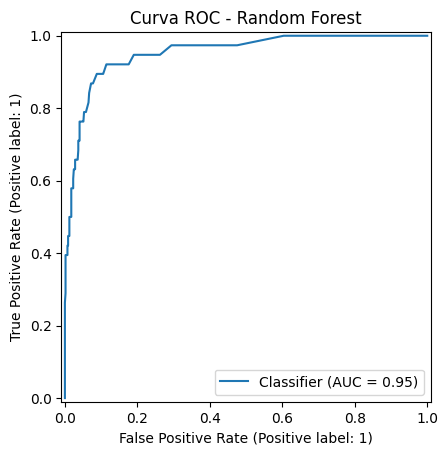

In [ ]:
# ============================================================
# BLOCO 6 — AVALIAÇÃO DO MODELO BASELINE
# Objetivo:
# - Gerar previsões no conjunto de teste
# - Avaliar acurácia, matriz de confusão e relatório de classificação
# - Calcular ROC-AUC e plotar a curva ROC
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)
import matplotlib.pyplot as plt

# Previsões
y_pred = pipeline_rf.predict(X_test)
y_prob = pipeline_rf.predict_proba(X_test)[:, 1]

# Métricas
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Acurácia:", round(acc, 4))
print("ROC-AUC :", round(auc, 4))

print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y_pred))

print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred, digits=4))

# Curva ROC
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("Curva ROC - Random Forest")
plt.show()

## **Conclusão da avaliação inicial**

O modelo Random Forest apresentou desempenho global muito bom, com:

* Acurácia: 95,71%

* ROC-AUC: 95,33%

Esses números mostram que a modelagem inicial foi bem-sucedida. No entanto, como o problema é desbalanceado e o foco prático está na identificação de alunos em risco de defasagem, a métrica mais sensível neste contexto é **o recall da classe 1, que ficou em 44,74%**.

Assim, apesar do bom desempenho geral, ainda há espaço para melhoria. Os próximos passos devem buscar aumentar a capacidade de detecção da classe de risco, mesmo que isso implique aceitar um pequeno aumento de falsos positivos.

## **IMPORTANTE**

**Por que o recall da classe 1 é tão importante neste problema**

Neste projeto, a classe 1 representa os alunos com risco de defasagem, ou seja, justamente o grupo que a análise preditiva deseja identificar com antecedência para possibilitar ações de acompanhamento e intervenção.

Por esse motivo, o recall da classe 1 é uma métrica especialmente relevante. Ele mede a proporção de alunos realmente em risco que o modelo conseguiu identificar corretamente.

A fórmula, em termos simples, é:

* recall = verdadeiros positivos / (verdadeiros positivos + falsos negativos)

No resultado obtido:

* 17 alunos em risco foram corretamente identificados;

* 21 alunos em risco não foram detectados.

Assim, o **recall da classe 1 ficou em aproximadamente 44,74%, o que significa que o modelo encontrou menos da metade dos casos reais de risco presentes no conjunto de teste**.

Essa métrica é crítica porque, neste contexto, um falso negativo é mais preocupante do que um falso positivo:

* Falso negativo: o aluno está em risco, mas o modelo não sinaliza;

* Falso positivo: o aluno é sinalizado como risco, mas na prática não estava.

Em aplicações educacionais preventivas, deixar de identificar um aluno realmente em risco pode significar perder a oportunidade de agir a tempo. Já um falso positivo, embora gere atenção desnecessária em alguns casos, costuma ser menos grave do que não detectar quem realmente precisa de apoio.

Por isso, mesmo com acurácia elevada e ROC-AUC excelente, a análise do modelo precisa dar atenção especial ao recall da classe 1. Em outras palavras: não basta o modelo ser bom no geral; ele precisa ser bom, principalmente, em encontrar os alunos que mais importam para a intervenção.

In [ ]:
# ============================================================
# BLOCO 7 — AVALIAÇÃO DE DIFERENTES LIMIARES DE DECISÃO
# Objetivo:
# - Testar diferentes thresholds para a classe 1
# - Comparar precision, recall e f1-score
# - Apoiar a escolha de um limiar mais adequado
# ============================================================

import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

limiares = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20]

resultados_limiares = []

for limiar in limiares:
    y_pred_limiar = (y_prob >= limiar).astype(int)

    precision = precision_score(y_test, y_pred_limiar, zero_division=0)
    recall = recall_score(y_test, y_pred_limiar, zero_division=0)
    f1 = f1_score(y_test, y_pred_limiar, zero_division=0)
    matriz = confusion_matrix(y_test, y_pred_limiar)

    resultados_limiares.append({
        "limiar": limiar,
        "precision_classe_1": round(precision, 4),
        "recall_classe_1": round(recall, 4),
        "f1_classe_1": round(f1, 4),
        "tn": matriz[0, 0],
        "fp": matriz[0, 1],
        "fn": matriz[1, 0],
        "tp": matriz[1, 1]
    })

df_limiares = pd.DataFrame(resultados_limiares)
display(df_limiares)

,limiar,precision_classe_1,recall_classe_1,f1_classe_1,tn,fp,fn,tp
0,0.50,0.7727,0.4474,0.5667,563,5,21,17
1,0.45,0.7727,0.4474,0.5667,563,5,21,17
2,0.40,0.7200,0.4737,0.5714,561,7,20,18
3,0.35,0.6552,0.5000,0.5672,558,10,19,19
4,0.30,0.6286,0.5789,0.6027,555,13,16,22
5,0.25,0.6098,0.6579,0.6329,552,16,13,25
6,0.20,0.5400,0.7105,0.6136,545,23,11,27


## **Escolha do limiar com foco preventivo**

A análise dos limiares mostrou que o **valor de 0,20** produziu o maior recall da classe 1, **alcançando 71,05% dos alunos em risco no conjunto de teste**.

Embora esse limiar apresente redução de precisão em relação a pontos de corte mais altos, sua adoção é justificável neste contexto, pois **o objetivo principal do modelo é ampliar a identificação precoce de estudantes com risco de defasagem**, aumentando o Falso positivo de alunos que não estão em RISCO e cairem nessa situação.

No contexto educacional, um **falso negativo** tende a ser mais preocupante do que um falso positivo, pois representa um aluno realmente em risco que deixa de ser sinalizado para acompanhamento. Já o falso positivo, embora gere atenção adicional, pode ser absorvido com menor impacto em uma estratégia preventiva.

Dessa forma, optou-se por adotar o **limiar 0,20** como ponto de corte final do modelo, privilegiando a sensibilidade na detecção dos casos de risco.

In [ ]:
# ============================================================
# BLOCO 8 — AVALIAÇÃO FINAL COM LIMIAR AJUSTADO
# Objetivo:
# - Aplicar o limiar final de 0,20
# - Recalcular matriz de confusão e métricas
# - Registrar o desempenho final do modelo
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Limiar final adotado
limiar_final = 0.20

# Previsões ajustadas
y_pred_final = (y_prob >= limiar_final).astype(int)

# Métricas finais
acc_final = accuracy_score(y_test, y_pred_final)
matriz_final = confusion_matrix(y_test, y_pred_final)
relatorio_final = classification_report(y_test, y_pred_final, digits=4)

print("Limiar final adotado:", limiar_final)
print("Acurácia final:", round(acc_final, 4))

print("\nMatriz de confusão final:")
print(matriz_final)

print("\nRelatório de classificação final:")
print(relatorio_final)

Limiar final adotado: 0.2
Acurácia final: 0.9439

Matriz de confusão final:
[[545  23]
 [ 11  27]]

Relatório de classificação final:
              precision    recall  f1-score   support

           0     0.9802    0.9595    0.9698       568
           1     0.5400    0.7105    0.6136        38

    accuracy                         0.9439       606
   macro avg     0.7601    0.8350    0.7917       606
weighted avg     0.9526    0.9439    0.9474       606



## **Análise da Matriz**

Com a adoção do limiar 0,20, a matriz de confusão final apresentou os seguintes resultados:

* 545 verdadeiros negativos: alunos sem risco corretamente classificados;

* 27 verdadeiros positivos: alunos em risco corretamente identificados;

* 23 falsos positivos: alunos sem risco classificados como risco;

* 11 falsos negativos: alunos em risco que não foram identificados pelo modelo.

Comparando com o limiar padrão de 0,50, houve uma melhora importante na capacidade de detectar alunos em risco:

* os verdadeiros positivos subiram de 17 para 27;

* os falsos negativos caíram de 21 para 11.

Isso mostra que o ajuste do limiar tornou o modelo mais sensível à classe de risco, o que é desejável em um cenário de prevenção.

## **Interpretação do Relatório de Classificação**

**Classe 0 — sem risco de defasagem**

* Precision: 0,9802

* Recall: 0,9595

* F1-score: 0,9698

O modelo continuou com desempenho muito forte para a classe majoritária, mantendo alta capacidade de classificar corretamente os alunos sem risco.

**Classe 1 — com risco de defasagem**

* Precision: 0,5400

* Recall: 0,7105

* F1-score: 0,6136

Para a classe de risco, o comportamento ficou mais alinhado ao objetivo do projeto. O modelo passou a identificar 71,05% dos casos reais de risco, o que representa um avanço importante em relação ao limiar padrão.

Houve queda de precisão, o que significa aumento de falsos positivos, mas esse efeito é aceitável dentro de uma estratégia preventiva, em que vale mais sinalizar alguns casos extras do que deixar passar alunos realmente vulneráveis.

## **Comparação entre o limiar padrão e o limiar ajustado**

Comparando os dois cenários:

**Limiar 0,50**

* Precision classe 1: 0,7727

* Recall classe 1: 0,4474

* F1-score classe 1: 0,5667

**Limiar 0,20**

* Precision classe 1: 0,5400

* Recall classe 1: 0,7105

* F1-score classe 1: 0,6136

Essa comparação mostra que o limiar 0,20 sacrificou parte da precisão, mas entregou ganho relevante em recall e também melhorou o F1-score, tornando o modelo mais útil para identificação precoce de risco.

## **Conclusão final do modelo**

O modelo final, baseado em Random Forest com limiar ajustado para 0,20, apresentou desempenho global sólido e, principalmente, maior sensibilidade para identificar alunos em risco de defasagem.

Os principais resultados finais foram:

* Acurácia: 94,39%

* Recall da classe 1: 71,05%

* F1-score da classe 1: 61,36%

Esses resultados indicam que o modelo é capaz de funcionar como ferramenta de apoio para sinalização preventiva de alunos com maior probabilidade de defasagem, oferecendo uma base objetiva para priorização de acompanhamento pedagógico.

Em termos práticos, o ajuste do limiar tornou o modelo mais aderente ao problema de negócio: em vez de apenas acertar muito no geral, ele passou a cumprir melhor o papel de encontrar quem realmente precisa de atenção.

Top 20 variáveis mais importantes:


,variavel,importancia
0,num__IAN,0.146020
1,num__Idade,0.062824
2,num__INDE 22,0.054672
3,num__Nº Av,0.047285
4,num__IPV,0.038306
5,cat__Instituição de ensino_Escola Pública,0.036229
6,num__IEG,0.034955
7,num__IDA,0.031481
8,num__Ano ingresso,0.030273
9,num__IAA,0.028728


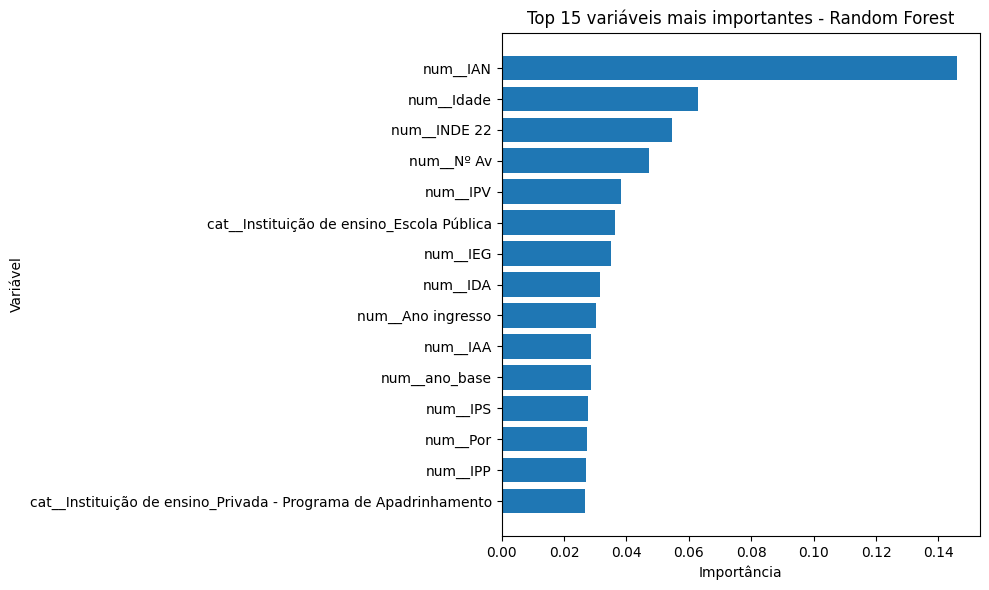

In [ ]:
# ============================================================
# BLOCO 9 — IMPORTÂNCIA DAS VARIÁVEIS
# Objetivo:
# - Recuperar os nomes das variáveis após o pré-processamento
# - Extrair a importância calculada pelo Random Forest
# - Exibir ranking das variáveis mais relevantes
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Recuperar o pré-processador e o modelo treinado
preprocessador_ajustado = pipeline_rf.named_steps["preprocessador"]
modelo_ajustado = pipeline_rf.named_steps["modelo"]

# Nomes finais das variáveis após transformação
nomes_features = preprocessador_ajustado.get_feature_names_out()

# Importâncias do modelo
importancias = modelo_ajustado.feature_importances_

# DataFrame de importância
df_importancias = pd.DataFrame({
    "variavel": nomes_features,
    "importancia": importancias
}).sort_values("importancia", ascending=False).reset_index(drop=True)

# Exibir top 20
print("Top 20 variáveis mais importantes:")
display(df_importancias.head(20))

# Gráfico
top_n = 15
df_top = df_importancias.head(top_n).sort_values("importancia", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(df_top["variavel"], df_top["importancia"])
plt.title("Top 15 variáveis mais importantes - Random Forest")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.tight_layout()
plt.show()

Para fins de interpretação analítica e registro metodológico, os indicadores considerados no projeto possuem o seguinte significado:

* IAN — indicador relacionado à defasagem de aprendizagem / nível de atenção acadêmica
* IDA — indicador de desempenho acadêmico (aprendizagem)
* IEG — indicador de engajamento do aluno
* IAA — indicador de autoavaliação do aluno
* IPV — indicador associado ao ponto de virada / proximidade de mudança de trajetória
* IPS — indicador de percepção ou componente socioemocional, conforme definição da base
* IPP — indicador ligado ao protagonismo / permanência / participação, conforme o conceito adotado
* INDE — índice consolidado de desenvolvimento educacional

Essas definições serão utilizadas como referência para a interpretação das variáveis no modelo preditivo e na análise dos fatores associados ao risco de defasagem.

Com issoa a análise de importância das variáveis mostrou que o modelo concentrou maior peso em indicadores educacionais e contextuais diretamente relacionados à trajetória do aluno.

O destaque principal foi o IAN, indicador associado à defasagem de aprendizagem e ao nível de atenção acadêmica, sugerindo forte relação com o risco previsto pelo modelo. Em seguida, apareceram variáveis como Idade, INDE 22, Nº Av, IPV, IEG, IDA, IAA, IPS e IPP, reforçando que a previsão do risco não depende de um único fator, mas de uma combinação entre desempenho, engajamento, autoavaliação, participação e histórico educacional.

Também surgiram variáveis ligadas à instituição de ensino, indicando que o contexto escolar pode influenciar a probabilidade de defasagem observada pelo modelo.

De forma geral, o resultado mostra que o modelo aprendeu com sinais coerentes com o problema analisado, apoiando-se principalmente em dimensões pedagógicas e de acompanhamento educacional.

________________________________________________________________________________
##  **Teste de robustez do modelo sem a variável IAN**

O objetivo dessa etapa é verificar se o desempenho do modelo se mantém em nível satisfatório mesmo sem o principal atributo. Esse teste é importante para avaliar a robustez da solução e reduzir o risco de dependência excessiva de uma única variável.

Se o modelo continuar apresentando bom desempenho sem o IAN, isso indica que a previsão também está sendo sustentada por outros sinais relevantes da base, como desempenho acadêmico, engajamento, autoavaliação, participação e contexto escolar.


In [ ]:
# ============================================================
# BLOCO 10 — MODELO SEM A VARIÁVEL IAN
# Objetivo:
# - Remover a variável IAN do conjunto de entrada
# - Treinar novamente o Random Forest
# - Avaliar o desempenho no conjunto de teste
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# Remover IAN do treino e do teste
X_train_sem_ian = X_train.drop(columns=["IAN"])
X_test_sem_ian = X_test.drop(columns=["IAN"])

# Separar colunas numéricas e categóricas
colunas_numericas_sem_ian = X_train_sem_ian.select_dtypes(include=["int64", "float64"]).columns.tolist()
colunas_categoricas_sem_ian = X_train_sem_ian.select_dtypes(include=["object"]).columns.tolist()

print("Colunas numéricas:", colunas_numericas_sem_ian)
print("\nColunas categóricas:", colunas_categoricas_sem_ian)

# Pipeline numérico
transformador_numerico_sem_ian = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Pipeline categórico
transformador_categorico_sem_ian = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Pré-processador
preprocessador_sem_ian = ColumnTransformer(transformers=[
    ("num", transformador_numerico_sem_ian, colunas_numericas_sem_ian),
    ("cat", transformador_categorico_sem_ian, colunas_categoricas_sem_ian)
])

# Modelo
modelo_rf_sem_ian = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

# Pipeline final
pipeline_rf_sem_ian = Pipeline(steps=[
    ("preprocessador", preprocessador_sem_ian),
    ("modelo", modelo_rf_sem_ian)
])

# Treinamento
pipeline_rf_sem_ian.fit(X_train_sem_ian, y_train)

# Probabilidades e previsão com limiar 0,20
y_prob_sem_ian = pipeline_rf_sem_ian.predict_proba(X_test_sem_ian)[:, 1]
y_pred_sem_ian = (y_prob_sem_ian >= 0.20).astype(int)

# Métricas
acc_sem_ian = accuracy_score(y_test, y_pred_sem_ian)
auc_sem_ian = roc_auc_score(y_test, y_prob_sem_ian)

print("\nAcurácia:", round(acc_sem_ian, 4))
print("ROC-AUC :", round(auc_sem_ian, 4))

print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y_pred_sem_ian))

print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred_sem_ian, digits=4))

Colunas numéricas: ['Ano ingresso', 'Nº Av', 'IAA', 'IEG', 'IPS', 'IDA', 'IPV', 'ano_base', 'INDE 22', 'IPP', 'Mat', 'Por', 'Idade']

Colunas categóricas: ['Fase', 'Turma', 'Gênero', 'Instituição de ensino', 'Pedra 22']

Acurácia: 0.9488
ROC-AUC : 0.9457

Matriz de confusão:
[[550  18]
 [ 13  25]]

Relatório de classificação:
              precision    recall  f1-score   support

           0     0.9769    0.9683    0.9726       568
           1     0.5814    0.6579    0.6173        38

    accuracy                         0.9488       606
   macro avg     0.7792    0.8131    0.7949       606
weighted avg     0.9521    0.9488    0.9503       606



In [ ]:
# ============================================================
# BLOCO 10.1 — TESTE DE DIFERENTES LIMIARES NO MODELO SEM IAN
# Objetivo:
# - Avaliar diferentes thresholds no modelo sem IAN
# - Comparar precision, recall e f1-score
# - Escolher o melhor limiar para esse novo cenário
# ============================================================

import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

limiares_sem_ian = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20]

resultados_limiares_sem_ian = []

for limiar in limiares_sem_ian:
    y_pred_limiar_sem_ian = (y_prob_sem_ian >= limiar).astype(int)

    precision = precision_score(y_test, y_pred_limiar_sem_ian, zero_division=0)
    recall = recall_score(y_test, y_pred_limiar_sem_ian, zero_division=0)
    f1 = f1_score(y_test, y_pred_limiar_sem_ian, zero_division=0)
    matriz = confusion_matrix(y_test, y_pred_limiar_sem_ian)

    resultados_limiares_sem_ian.append({
        "limiar": limiar,
        "precision_classe_1": round(precision, 4),
        "recall_classe_1": round(recall, 4),
        "f1_classe_1": round(f1, 4),
        "tn": matriz[0, 0],
        "fp": matriz[0, 1],
        "fn": matriz[1, 0],
        "tp": matriz[1, 1]
    })

df_limiares_sem_ian = pd.DataFrame(resultados_limiares_sem_ian)
display(df_limiares_sem_ian)

,limiar,precision_classe_1,recall_classe_1,f1_classe_1,tn,fp,fn,tp
0,0.50,0.7619,0.4211,0.5424,563,5,22,16
1,0.45,0.7727,0.4474,0.5667,563,5,21,17
2,0.40,0.6923,0.4737,0.5625,560,8,20,18
3,0.35,0.6786,0.5000,0.5758,559,9,19,19
4,0.30,0.6364,0.5526,0.5915,556,12,17,21
5,0.25,0.6154,0.6316,0.6234,553,15,14,24
6,0.20,0.5814,0.6579,0.6173,550,18,13,25


## **Escolha do limiar no modelo sem IAN**

Após o teste de diferentes limiares no modelo sem a variável IAN, observou-se que o ponto de corte 0,25 apresentou o melhor equilíbrio entre precision, recall e F1-score para a classe de risco.

Os resultados nesse limiar foram:

* precision: 0,6154

* recall: 0,6316

* F1-score: 0,6234

Embora o limiar 0,20 tenha produzido recall ligeiramente maior, o valor de 0,25 apresentou melhor equilíbrio geral e maior F1-score, sendo mais adequado para representar o desempenho do modelo sem IAN.

Dessa forma, o limiar 0,25 foi adotado como ponto de corte final para a avaliação comparativa dessa segunda versão do modelo.

In [ ]:
# ============================================================
# BLOCO 10.2 — AVALIAÇÃO FINAL DO MODELO SEM IAN
# Objetivo:
# - Aplicar o limiar final de 0,25 no modelo sem IAN
# - Recalcular métricas e matriz de confusão
# - Registrar a versão final comparável do modelo sem IAN
# ============================================================

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Limiar final do modelo sem IAN
limiar_final_sem_ian = 0.25

# Previsões finais
y_pred_final_sem_ian = (y_prob_sem_ian >= limiar_final_sem_ian).astype(int)

# Métricas finais
acc_final_sem_ian = accuracy_score(y_test, y_pred_final_sem_ian)
matriz_final_sem_ian = confusion_matrix(y_test, y_pred_final_sem_ian)
relatorio_final_sem_ian = classification_report(y_test, y_pred_final_sem_ian, digits=4)

print("Limiar final adotado (sem IAN):", limiar_final_sem_ian)
print("Acurácia final:", round(acc_final_sem_ian, 4))

print("\nMatriz de confusão final:")
print(matriz_final_sem_ian)

print("\nRelatório de classificação final:")
print(relatorio_final_sem_ian)

Limiar final adotado (sem IAN): 0.25
Acurácia final: 0.9521

Matriz de confusão final:
[[553  15]
 [ 14  24]]

Relatório de classificação final:
              precision    recall  f1-score   support

           0     0.9753    0.9736    0.9744       568
           1     0.6154    0.6316    0.6234        38

    accuracy                         0.9521       606
   macro avg     0.7953    0.8026    0.7989       606
weighted avg     0.9527    0.9521    0.9524       606



## **Comparação entre os modelos com e sem IAN**

A comparação mostrou que os dois modelos apresentaram desempenho satisfatório, mas com características distintas.

O **modelo com IAN** apresentou maior capacidade de detecção da classe de risco, alcançando recall de 71,05%, o que o torna mais adequado quando a prioridade é ampliar a identificação de alunos potencialmente vulneráveis.

Por outro lado, o **modelo sem IAN** apresentou melhor equilíbrio geral, com acurácia de 95,21%, precision de 61,54% e F1-score de 62,34% para a classe 1. Esse resultado sugere uma solução mais robusta e menos dependente de uma única variável dominante.



## **Conclusão da Pergunta 9**

A modelagem preditiva desenvolvida para estimar o risco de defasagem dos alunos mostrou que é possível identificar, com bom nível de desempenho, padrões associados à vulnerabilidade educacional a partir dos indicadores disponíveis na base.

Os testes realizados com **Random Forest** indicaram que o problema pode ser tratado de forma eficaz mesmo em um cenário de forte desbalanceamento entre as classes, desde que a avaliação priorize métricas adequadas, especialmente recall, precision e F1-score para a classe de risco.

**Dois cenários foram comparados:**

1) modelo com IAN, mais sensível para detectar alunos em risco;

2) modelo sem IAN, mais equilibrado e metodologicamente mais robusto.

O modelo com IAN alcançou maior capacidade de detecção dos casos de risco, com recall de 71,05%, sendo mais indicado quando o objetivo principal é maximizar a identificação preventiva de alunos vulneráveis.

Já o modelo sem IAN apresentou o melhor equilíbrio geral, com:

* acurácia de 95,21%

* precision de 61,54%

* recall de 63,16%

* F1-score de 62,34%

Esse resultado mostra que a solução continua forte mesmo sem depender da variável mais dominante (IAN), o que reforça sua consistência analítica.

De forma geral, a análise permite concluir que o uso de modelagem preditiva pode apoiar a Passos Mágicos na identificação antecipada de alunos com maior probabilidade de defasagem, contribuindo para priorização de acompanhamento, intervenções pedagógicas e ações preventivas mais direcionadas.

**Como encaminhamento prático, o modelo sem IAN pode ser adotado como versão principal da solução por apresentar maior equilíbrio e robustez**, enquanto o modelo com IAN pode ser mantido como alternativa complementar em cenários nos quais a prioridade seja ampliar ao máximo a sensibilidade para detecção de risco.

--------------------------------------------------------------------------------
## **Salvando o modelo final para uso no Streamlit**

Após a definição do modelo final, será necessário salvar em arquivo os objetos que serão utilizados na aplicação.

Nesta etapa serão armazenados:

* o pipeline treinado, contendo o pré-processamento e o modelo;

* o limiar de decisão final adotado;

* a lista de colunas de entrada esperadas pelo modelo.

Essa abordagem facilita a reutilização da solução preditiva fora do notebook, garantindo que o Streamlit aplique exatamente o mesmo fluxo utilizado no treinamento.

In [ ]:
import sklearn
import joblib

# Verificar a versão (deve ser 1.4+ ou 1.5+)
print(f"Versão do sklearn no Colab: {sklearn.__version__}")

Versão do sklearn no Colab: 1.6.1


In [ ]:
# ============================================================
# BLOCO 11 — SALVAR MODELO FINAL PARA USO NO STREAMLIT
# Objetivo:
# - Salvar o pipeline treinado
# - Salvar o limiar final
# - Salvar a lista de colunas esperadas
# ============================================================

import os
import joblib

# Pasta onde os artefatos serão salvos
PASTA_MODELO = "/content/fase5/models"
os.makedirs(PASTA_MODELO, exist_ok=True)

# Definir o artefato final
artefato_modelo = {
    "pipeline": pipeline_rf_sem_ian,
    "limiar": 0.25,
    "colunas_entrada": X_train_sem_ian.columns.tolist(),
    "nome_modelo": "RandomForest_sem_IAN",
    "versao": "v1"
}

# Caminho do arquivo
CAMINHO_MODELO = os.path.join(PASTA_MODELO, "modelo_risco_defasagem_rf_sem_ian.joblib")

# Salvar
joblib.dump(artefato_modelo, CAMINHO_MODELO)

print("Modelo salvo com sucesso em:")
print(CAMINHO_MODELO)

Modelo salvo com sucesso em:
/content/fase5/models/modelo_risco_defasagem_rf_sem_ian.joblib


In [ ]:
X.head()

,Fase,Turma,Gênero,Ano ingresso,Instituição de ensino,Nº Av,IAA,IEG,IPS,IDA,IPV,IAN,ano_base,INDE 22,Pedra 22,IPP,Mat,Por,Idade
0,7,A,Menina,2016,Escola Pública,4.0,8.3,4.1,5.6,4.0,7.278,5.0,2022,5.783,Quartzo,NaN,NaN,NaN,NaN
1,7,A,Menina,2017,Rede Decisão,4.0,8.8,5.2,6.3,6.8,6.778,10.0,2022,7.055,Ametista,NaN,NaN,NaN,NaN
2,7,A,Menina,2016,Rede Decisão,4.0,0.0,7.9,5.6,5.6,7.556,10.0,2022,6.591,Ágata,NaN,NaN,NaN,NaN
3,7,A,Menino,2017,Rede Decisão,4.0,8.8,4.5,5.6,5.0,5.278,10.0,2022,5.951,Quartzo,NaN,NaN,NaN,NaN
4,7,A,Menina,2016,Rede Decisão,4.0,7.9,8.6,5.6,5.2,7.389,10.0,2022,7.427,Ametista,NaN,NaN,NaN,NaN


## **Versionando o modelo no GitHub**

Após salvar o artefato do modelo em arquivo .joblib, o próximo passo é incluí-lo no repositório GitHub do projeto.

Nesta etapa, o arquivo será:

1) verificado no diretório do repositório;

2) adicionado ao controle de versão;

3) registrado com commit;

4) enviado ao GitHub com push.

Isso permite reutilizar o modelo posteriormente no Streamlit e manter a solução preditiva versionada junto com o restante do projeto.

In [ ]:
# ============================================================
# BLOCO 11.1 — CONFIGURAÇÃO E CONFERÊNCIA
# ============================================================

import os
import subprocess
import shutil
from google.colab import userdata

REPO_DIR = "/content/fase5"
ARQUIVO_MODELO = "models/modelo_risco_defasagem_rf_sem_ian.joblib"

# Carregar token do Colab
TOKEN = userdata.get("GITHUB_TOKEN")

# Criar script seguro para fornecer o token ao Git
with open("/tmp/git-askpass.sh", "w") as f:
    f.write(f'#!/bin/sh\necho "{TOKEN}"\n')

os.chmod("/tmp/git-askpass.sh", 0o700)

# Variáveis obrigatórias para autenticação via token
os.environ["GIT_ASKPASS"] = "/tmp/git-askpass.sh"
os.environ["GIT_TERMINAL_PROMPT"] = "0"
os.environ["GIT_USERNAME"] = "oauth2"   # obrigatório para GitHub

def run(cmd):
    r = subprocess.run(cmd, capture_output=True, text=True)
    print("CMD:", " ".join(cmd))
    if r.stdout.strip():
        print("\nSTDOUT:\n", r.stdout)
    if r.stderr.strip():
        print("\nSTDERR:\n", r.stderr)
    print("-" * 80)
    return r

# Remover diretório se já existir para evitar o erro fatal
if os.path.exists(REPO_DIR):
    print(f"Limpando diretório existente: {REPO_DIR}")
    shutil.rmtree(REPO_DIR)

# Clonar o repositório sem token
run(["git", "clone", "https://github.com/tivanello/fase5.git", REPO_DIR])

# Configurar identidade do Git no repositório
run(["git", "-C", REPO_DIR, "config", "user.name", "tivanello"])
run(["git", "-C", REPO_DIR, "config", "user.email", "tivanello@example.com"])

Limpando diretório existente: /content/fase5
CMD: git clone https://github.com/tivanello/fase5.git /content/fase5

STDERR:
 Cloning into '/content/fase5'...

--------------------------------------------------------------------------------
CMD: git -C /content/fase5 config user.name tivanello
--------------------------------------------------------------------------------
CMD: git -C /content/fase5 config user.email tivanello@example.com
--------------------------------------------------------------------------------


CompletedProcess(args=['git', '-C', '/content/fase5', 'config', 'user.email', 'tivanello@example.com'], returncode=0, stdout='', stderr='')

In [ ]:
# ============================================================
# BLOCO 11.2 — ADICIONAR E COMMITAR O MODELO
# Objetivo:
# - Adicionar o arquivo .joblib ao Git
# - Criar o commit local
# ============================================================

run(["git", "-C", REPO_DIR, "add", ARQUIVO_MODELO])
run(["git", "-C", REPO_DIR, "status", "--short"])
run([
    "git", "-C", REPO_DIR, "commit",
    "-m", "Adiciona modelo preditivo Random Forest sem IAN para uso no Streamlit"
])

CMD: git -C /content/fase5 add models/modelo_risco_defasagem_rf_sem_ian.joblib
--------------------------------------------------------------------------------
CMD: git -C /content/fase5 status --short
--------------------------------------------------------------------------------
CMD: git -C /content/fase5 commit -m Adiciona modelo preditivo Random Forest sem IAN para uso no Streamlit

STDOUT:
 On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean

--------------------------------------------------------------------------------


CompletedProcess(args=['git', '-C', '/content/fase5', 'commit', '-m', 'Adiciona modelo preditivo Random Forest sem IAN para uso no Streamlit'], returncode=1, stdout="On branch main\nYour branch is up to date with 'origin/main'.\n\nnothing to commit, working tree clean\n", stderr='')

In [ ]:
# ============================================================
# BLOCO 11.3 — PUSH FINAL E SEGURO
# ============================================================
import os
import subprocess
from google.colab import userdata

# 1. Recuperar o novo token e infos do repo
TOKEN = userdata.get("GITHUB_TOKEN")
USER = "tivanello"
REPO = "fase5"

# 2. Montar a URL de autenticação (fica apenas na memória)
url_autenticada = f"https://{TOKEN}@github.com/{USER}/{REPO}.git"

print("🚀 Iniciando o upload do modelo para o GitHub...")

try:
    # O push envia o conteúdo da pasta local /content/fase5 para o repo remoto
    # Usamos capture_output para o token não vazar no log em caso de erro
    subprocess.run(
        ["git", "-C", REPO_DIR, "push", url_autenticada, "main"],
        check=True, capture_output=True, text=True
    )
    print("\n✅ SUCESSO! O arquivo .joblib foi enviado corretamente.")
    print(f"🔗 Link do repo: https://github.com/{USER}/{REPO}")

except subprocess.CalledProcessError as e:
    # Se falhar, limpamos qualquer rastro do token antes de exibir a mensagem
    erro_seguro = e.stderr.replace(TOKEN, "********")
    print(f"\n❌ Erro no push:\n{erro_seguro}")
    print("\nDica: Verifique se o nome da branch no GitHub é realmente 'main'.")

🚀 Iniciando o upload do modelo para o GitHub...

✅ SUCESSO! O arquivo .joblib foi enviado corretamente.
🔗 Link do repo: https://github.com/tivanello/fase5


Após realizar testes na aplicação desenvolvida em Streamlit, identifiquei um desalinhamento entre as variáveis utilizadas no treinamento do modelo e os campos efetivamente disponibilizados na interface para entrada de dados, deixado da forma que estava ficaria muito poluida a aplicação.

A versão inicialmente treinada utilizava um conjunto mais amplo de atributos, incluindo variáveis. Na prática, isso comprometia a consistência entre o que o modelo esperava receber e o que o usuário realmente podia informar no momento da predição.

Diante dessa constatação, decidi retornar ao Colab para reestruturar a etapa de modelagem, redefinindo as variáveis de entrada X e a variável alvo y, de forma que o novo treinamento ficasse mais adequado a minha necessidade.

Essa revisão não altera o objetivo analítico do projeto, que continua sendo a predição do risco de defasagem acadêmica a partir dos indicadores do aluno. O que muda é a adequação da modelagem ao cenário real de uso da aplicação, tornando a solução mais consistente, interpretável e operacionalmente viável.

In [ ]:
df_novo_modelo.head()


,RA,Fase,Turma,Ano nasc,Idade 22,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,Pedra 21,...,FaseIdeal_txt,Fase_num,Fase_sufixo,FaseIdeal_num,ra_num,INDE_final,INDE_fonte,PEDRA_final,PEDRA_fonte,alvo_risco_defasagem
0,RA-1,7,A,2003.0,19.0,Menina,2016,Escola Pública,Ametista,Ametista,...,Fase 8 (Universitários),7.0,NaN,8,1,5.783,INDE 2022,Quartzo,Pedra 2022,0
1,RA-2,7,A,2005.0,17.0,Menina,2017,Rede Decisão,Ametista,Ametista,...,Fase 7 (3º EM),7.0,NaN,7,2,7.055,INDE 2022,Ametista,Pedra 2022,0
2,RA-3,7,A,2005.0,17.0,Menina,2016,Rede Decisão,Ametista,Ametista,...,Fase 7 (3º EM),7.0,NaN,7,3,6.591,INDE 2022,Ágata,Pedra 2022,0
3,RA-4,7,A,2005.0,17.0,Menino,2017,Rede Decisão,Ametista,Ametista,...,Fase 7 (3º EM),7.0,NaN,7,4,5.951,INDE 2022,Quartzo,Pedra 2022,0
4,RA-5,7,A,2005.0,17.0,Menina,2016,Rede Decisão,Ametista,Ametista,...,Fase 7 (3º EM),7.0,NaN,7,5,7.427,INDE 2022,Ametista,Pedra 2022,0


In [ ]:
# ============================================================
# BLOCO 12 — DEFINIR y E X REDUZIDO PARA O df_novo_modelo
# Objetivo:
# - Criar X e y para o novo modelo do Streamlit
# - Usar o df_novo_modelo criado no BLOCO 3.01
# - Preservar o fluxo do modelo original
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1) Trabalhar sobre o novo dataframe
# ------------------------------------------------------------
df_novo_modelo = df_novo_modelo.copy()

# ------------------------------------------------------------
# 2) Garantir a variável-alvo no novo dataframe
# Mantendo a mesma lógica adotada no projeto:
# 1 = aluno com risco de defasagem
# 0 = aluno sem risco
# ------------------------------------------------------------
df_novo_modelo["target_risco_defasagem"] = (
    df_novo_modelo["Defasagem_final"] > 0
).astype(int)

# ------------------------------------------------------------
# 3) Definir colunas do novo modelo alinhadas ao Streamlit
# ------------------------------------------------------------
colunas_novo_modelo = [
    "Fase",
    "Gênero",
    "Instituição de ensino",
    "Idade",
    "IAA",
    "IEG",
    "IPS",
    "IDA",
    "IPV",
    "INDE 22"
]

# ------------------------------------------------------------
# 4) Manter apenas colunas necessárias
# ------------------------------------------------------------
colunas_necessarias_novo_modelo = colunas_novo_modelo + ["target_risco_defasagem"]
df_novo_modelo_base = df_novo_modelo[colunas_necessarias_novo_modelo].copy()

# ------------------------------------------------------------
# 5) Criar X_novo e y_novo
# Sem remover nulos aqui.
# O tratamento será feito no pipeline, como no fluxo original.
# ------------------------------------------------------------
X_novo = df_novo_modelo_base[colunas_novo_modelo].copy()
y_novo = df_novo_modelo_base["target_risco_defasagem"].copy()

# ------------------------------------------------------------
# 6) Conferência rápida
# ------------------------------------------------------------
print("Dimensão de df_novo_modelo_base:", df_novo_modelo_base.shape)
print("Dimensão de X_novo:", X_novo.shape)
print("Dimensão de y_novo:", y_novo.shape)

print("\nTipos de dados de X_novo:")
print(X_novo.dtypes)

print("\nColunas de X_novo:")
print(X_novo.columns.tolist())

print("\nQuantidade de nulos por coluna em X_novo:")
print(X_novo.isna().sum())

print("\nDistribuição de y_novo:")
print(y_novo.value_counts(dropna=False))

print("\nAmostra de X_novo:")
display(X_novo.head())

print("\nAmostra de y_novo:")
display(y_novo.head())

Dimensão de df_novo_modelo_base: (3030, 11)
Dimensão de X_novo: (3030, 10)
Dimensão de y_novo: (3030,)

Tipos de dados de X_novo:
Fase                      object
Gênero                    object
Instituição de ensino     object
Idade                    float64
IAA                      float64
IEG                      float64
IPS                      float64
IDA                      float64
IPV                      float64
INDE 22                  float64
dtype: object

Colunas de X_novo:
['Fase', 'Gênero', 'Instituição de ensino', 'Idade', 'IAA', 'IEG', 'IPS', 'IDA', 'IPV', 'INDE 22']

Quantidade de nulos por coluna em X_novo:
Fase                        0
Gênero                      0
Instituição de ensino       1
Idade                     860
IAA                       165
IEG                        76
IPS                       171
IDA                       178
IPV                       178
INDE 22                  1098
dtype: int64

Distribuição de y_novo:
target_risco_defasagem
0  

,Fase,Gênero,Instituição de ensino,Idade,IAA,IEG,IPS,IDA,IPV,INDE 22
0,7,Menina,Escola Pública,NaN,8.3,4.1,5.6,4.0,7.278,5.783
1,7,Menina,Rede Decisão,NaN,8.8,5.2,6.3,6.8,6.778,7.055
2,7,Menina,Rede Decisão,NaN,0.0,7.9,5.6,5.6,7.556,6.591
3,7,Menino,Rede Decisão,NaN,8.8,4.5,5.6,5.0,5.278,5.951
4,7,Menina,Rede Decisão,NaN,7.9,8.6,5.6,5.2,7.389,7.427



Amostra de y_novo:


,target_risco_defasagem
0,0
1,0
2,0
3,0
4,0


In [ ]:
# ============================================================
# BLOCO 12.1 — DIAGNÓSTICO DAS CATEGORIAS DO NOVO MODELO
# Objetivo:
# - Verificar valores únicos das variáveis categóricas
# - Identificar inconsistências de preenchimento
# - Apoiar a padronização antes do treino
# ============================================================

colunas_categoricas_diagnostico = [
    "Fase",
    "Gênero",
    "Instituição de ensino"
]

for col in colunas_categoricas_diagnostico:
    print(f"\n{'='*70}")
    print(f"Coluna: {col}")
    print(f"{'='*70}")
    print("Quantidade de nulos:", df_novo_modelo[col].isna().sum())
    print("Valores únicos:")
    print(sorted(df_novo_modelo[col].dropna().astype(str).unique()))


Coluna: Fase
Quantidade de nulos: 0
Valores únicos:
['0', '1', '1A', '1B', '1C', '1D', '1E', '1G', '1H', '1J', '1K', '1L', '1M', '1N', '1P', '1R', '2', '2A', '2B', '2C', '2D', '2G', '2H', '2I', '2K', '2L', '2M', '2N', '2P', '2R', '2U', '3', '3A', '3B', '3C', '3D', '3F', '3G', '3H', '3I', '3K', '3L', '3M', '3N', '3P', '3R', '3U', '4', '4A', '4B', '4C', '4F', '4H', '4L', '4M', '4N', '4R', '5', '5A', '5B', '5C', '5D', '5F', '5G', '5L', '5M', '5N', '6', '6A', '6L', '7', '7A', '7E', '8A', '8B', '8D', '8E', '8F', '9', 'ALFA', 'FASE 1', 'FASE 2', 'FASE 3', 'FASE 4', 'FASE 5', 'FASE 6', 'FASE 7', 'FASE 8']

Coluna: Gênero
Quantidade de nulos: 0
Valores únicos:
['Feminino', 'Masculino', 'Menina', 'Menino']

Coluna: Instituição de ensino
Quantidade de nulos: 1
Valores únicos:
['Bolsista Universitário *Formado (a)', 'Concluiu o 3º EM', 'Escola JP II', 'Escola Pública', 'Nenhuma das opções acima', 'Privada', 'Privada *Parcerias com Bolsa 100%', 'Privada - Pagamento por *Empresa Parceira', 'Privad

In [ ]:
# ============================================================
# BLOCO 13 — TRAIN/TEST SPLIT E DIAGNÓSTICO DAS VARIÁVEIS
# Objetivo:
# - Separar base de treino e teste do novo modelo
# - Identificar colunas numéricas e categóricas
# - Preparar a estrutura para o novo pipeline
# ============================================================

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# 1) Separar treino e teste
# ------------------------------------------------------------
X_train_novo, X_test_novo, y_train_novo, y_test_novo = train_test_split(
    X_novo,
    y_novo,
    test_size=0.2,
    random_state=42,
    stratify=y_novo
)

# ------------------------------------------------------------
# 2) Identificar colunas numéricas e categóricas
# ------------------------------------------------------------
colunas_numericas_novo = X_train_novo.select_dtypes(include=["int64", "float64"]).columns.tolist()
colunas_categoricas_novo = X_train_novo.select_dtypes(include=["object", "category"]).columns.tolist()

# ------------------------------------------------------------
# 3) Conferências
# ------------------------------------------------------------
print("Dimensão de X_train_novo:", X_train_novo.shape)
print("Dimensão de X_test_novo :", X_test_novo.shape)
print("Dimensão de y_train_novo:", y_train_novo.shape)
print("Dimensão de y_test_novo :", y_test_novo.shape)

print("\nColunas numéricas:")
print(colunas_numericas_novo)

print("\nColunas categóricas:")
print(colunas_categoricas_novo)

print("\nDistribuição de y_train_novo:")
print(y_train_novo.value_counts())
print(y_train_novo.value_counts(normalize=True).round(4))

print("\nDistribuição de y_test_novo:")
print(y_test_novo.value_counts())
print(y_test_novo.value_counts(normalize=True).round(4))

print("\nAmostra de X_train_novo:")
display(X_train_novo.head())

Dimensão de X_train_novo: (2424, 10)
Dimensão de X_test_novo : (606, 10)
Dimensão de y_train_novo: (2424,)
Dimensão de y_test_novo : (606,)

Colunas numéricas:
['Idade', 'IAA', 'IEG', 'IPS', 'IDA', 'IPV', 'INDE 22']

Colunas categóricas:
['Fase', 'Gênero', 'Instituição de ensino']

Distribuição de y_train_novo:
target_risco_defasagem
0    2271
1     153
Name: count, dtype: int64
target_risco_defasagem
0    0.9369
1    0.0631
Name: proportion, dtype: float64

Distribuição de y_test_novo:
target_risco_defasagem
0    568
1     38
Name: count, dtype: int64
target_risco_defasagem
0    0.9373
1    0.0627
Name: proportion, dtype: float64

Amostra de X_train_novo:


,Fase,Gênero,Instituição de ensino,Idade,IAA,IEG,IPS,IDA,IPV,INDE 22
450,2,Menina,Escola Pública,NaN,9.000,6.000000,6.300,6.100000,6.889000,6.434000
1347,FASE 2,Feminino,Pública,12.0,9.000,8.800000,2.520,8.400000,8.673333,7.729000
2522,3G,Masculino,Pública,15.0,7.917,6.166667,7.510,7.000000,6.702500,6.969182
2689,4C,Feminino,Privada - Programa de Apadrinhamento,15.0,6.667,9.523810,5.005,8.833333,8.950000,NaN
2117,1D,Masculino,Pública,11.0,9.002,4.545455,5.010,1.000000,6.245000,6.839365


In [ ]:
# ============================================================
# BLOCO 14 — PIPELINE E TREINAMENTO DO NOVO MODELO
# Objetivo:
# - Criar o pré-processamento para variáveis numéricas e categóricas
# - Montar o pipeline completo do novo modelo
# - Treinar o Random Forest sobre o novo conjunto reduzido
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

# ------------------------------------------------------------
# 1) Pipeline para colunas numéricas
# ------------------------------------------------------------
pipeline_numerico_novo = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# ------------------------------------------------------------
# 2) Pipeline para colunas categóricas
# ------------------------------------------------------------
pipeline_categorico_novo = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# ------------------------------------------------------------
# 3) Pré-processador geral
# ------------------------------------------------------------
preprocessador_novo = ColumnTransformer(transformers=[
    ("num", pipeline_numerico_novo, colunas_numericas_novo),
    ("cat", pipeline_categorico_novo, colunas_categoricas_novo)
])

# ------------------------------------------------------------
# 4) Pipeline final com Random Forest
# ------------------------------------------------------------
pipeline_rf_novo = Pipeline(steps=[
    ("preprocessador", preprocessador_novo),
    ("modelo", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        class_weight="balanced"
    ))
])

# ------------------------------------------------------------
# 5) Treinar o novo modelo
# ------------------------------------------------------------
pipeline_rf_novo.fit(X_train_novo, y_train_novo)

print("Novo pipeline treinado com sucesso.")
print("\nColunas numéricas usadas:")
print(colunas_numericas_novo)

print("\nColunas categóricas usadas:")
print(colunas_categoricas_novo)

In [ ]:
# ============================================================
# BLOCO DIAGNÓSTICO — RASTREAR ONDE A CODIFICAÇÃO QUEBRA
# Objetivo:
# - Verificar se a sujeira está no df_fase5 ou surgiu depois
# - Comparar nomes de colunas e valores categóricos críticos
# ============================================================

def diagnostico_texto(df, nome_df):
    print(f"\n{'='*80}")
    print(f"DIAGNÓSTICO: {nome_df}")
    print(f"{'='*80}")

    print("\nColunas:")
    print(df.columns.tolist())

    colunas_teste = [
        "Fase",
        "Turma",
        "Gênero",
        "Instituição de ensino",
        "Pedra 22"
    ]

    for col in colunas_teste:
        if col in df.columns:
            print(f"\n--- {col} ---")
            print("dtype:", df[col].dtype)
            print("Amostra valores únicos:")
            print(sorted(df[col].dropna().astype(str).unique())[:20])
        else:
            print(f"\n--- {col} ---")
            print("Coluna não encontrada")

# 1) Diagnóstico da base principal
diagnostico_texto(df_fase5, "df_fase5")

# 2) Se existir, diagnosticar a base do novo modelo
if "df_novo_modelo" in globals():
    diagnostico_texto(df_novo_modelo, "df_novo_modelo")


DIAGNÓSTICO: df_fase5

Colunas:
['RA', 'Fase', 'Turma', 'Ano nasc', 'Idade 22', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'INDE 22', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'Rec Psicologia', 'IDA', 'Matem', 'Portug', 'Inglês', 'Indicado', 'Atingiu PV', 'IPV', 'IAN', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV', 'ano_base', 'INDE 2023', 'Pedra 2023', 'Data de Nasc', 'Idade', 'Pedra 23', 'INDE 23', 'IPP', 'Mat', 'Por', 'Ing', 'INDE 2024', 'Pedra 2024', 'Avaliador5', 'Avaliador6', 'Escola', 'Ativo/ Inativo', 'Defasagem_final', 'Avaliador1_id', 'Avaliador2_id', 'Avaliador3_id', 'Avaliador4_id', 'Avaliador5_id', 'Avaliador6_id', 'FaseIdeal_txt', 'Fase_num', 'Fase_sufixo', 'FaseIdeal_num', 'ra_num', 'INDE_final', 'INDE_fonte', 'PEDRA_final', 'PEDRA_fonte']

--- Fase ---
dtype: object
Amostra valores únicos:
['0', '1', '1A', '1B', '1C', '1